# **Measure Organelle Distribution**

***Prior to this notebook, you should have already run through [2.0_quantification_setup](2.0_quantification_setup.ipynb) and have segmentation outputs of <ins>at least one</ins> organelle.***

In notebooks 2.1 through 2.4, we will go over the implementation of `infer-subc` quantification methods (explained in detail in the `method_...` notebooks) to assess the morphology, interactions, and distribution of organelles at the single-cell level. 

### 📍 **Purpose**
This notebook can be used to measure the `distribution` -- numerical description of spatial spread -- of one or more `organelles` from one or more cells. It includes options to:
1. 🦠 Quantify the distribution of *one or more organelle(s)* from <ins>ONE CELL</ins>
2. 🧪 Batch process the distribution of *one or more organelle(s)* from *multiple cells* for a <ins>SINGLE EXPERIMENT</ins>
3. 🧮 Summarize distribution metrics *per cell* across <INS>ONE OR MORE EXPERIMENTS</ins>

Below you will find an [`explanation of steps`](#explanation) for these three quantitative methods. Then, more succinct code blocks are included to [`execute quantification`](#execute) on your own (or sample) data.

### 🍃 **Biological Relevance - Organelle Distribution**
<mark>!!!INPUT BIOLOGICAL RELEVANCE LAST!!!

The following distribution-related measurements are included for each organelle:
- `scale`: The real-world dimensions in ZYX of the original raw microscopy image
- `object`: name object being measured

**<span style="background-color: #00812241">XY Distribution</span>**

- `XY_n_bins`: number of disjoint concentric bins that divide the 3D cell mask
- `XY_bins`: list of bin identification numbers
- `XY_mask_vox_cnt_perbin*`: number of voxels in the 3D mask per bin
- `XY_obj_vox_cnt_perbin*`: number of voxels of the 3D object per bin
- `XY_center_vox_cnt_perbin**`: number of voxels of the 3D centering object per bin
- `XY_n_pix_perbin*`: number of pixels per bin in the XY mask
- `XY_portion_pix_perbin`: the proportion of pixels from the XY mask per bin
- `XY_n_wedges`: number of wedges in each concentric bin
- `XY_wedges`: list of wedge identification numbers
- `XY_mask_vox_cnt_perwedge*`: number of voxels in the 3D cell mask per wedge
- `XY_obj_vox_cnt_perwedge*`: number of voxels of the 3D object per wedge
- `XY_center_vox_cnt_perwedge**`: number of voxels of the 3D centering object per wedge
- `XY_n_pix_perwedge*`: number of pixels from the XY mask per wedge
- `XY_portion_pix_perwedge`: the proportion of pixels from the XY mask per wedge
- `XY_wedges_perbin`: list of wedges that have >0 pixels from the XY mask per bin
- `XY_mask_vox_cnt_wedges_perbin*`: number of voxels in the 3D cell mask per wedge per bin
- `XY_obj_vox_cnt_wedges_perbin*`: number of voxels of the 3D object per wedge per bin
- `XY_center_vox_cnt_wedges_perbin**`: number of voxels of the 3D centering object per wedge per bin
- `XY_n_pix_wedges_perbin*`: number of pixels per wedge per bin in the XY mask
- `XY_mask_cv_perbin`: the coefficient of variance of the wedges' pixel count within each bin for the mask
- `XY_obj_cv_perbin`: the coefficient of variance of the wedges' pixel count within each bin for the object of interest
- `XY_center_cv_perbin`: the coefficient of variance of the wedges' pixel count within each bin for the centering object

**<span style="background-color: #00829c42">Z Distribution</span>**

- `Z_n_slices`: the number of z-slices in the raw image
- `Z_slices`: a numbered list representing each z-slice (first element of the list is 0)
- `Z_mask_vox_cnt*`: number of voxels in the 3D mask per z-slice
- `Z_obj_vox_cnt*`: number of voxels in the 3D object per z-slice
- `Z_center_vox_cnt**`: number of voxels of the 3D centering object per z-slice
- `Z_height*`: the height of the raw image in microns
- `Z_mask_volume*`: the amount of cell mask volume in cubic mircons per z-slice 
- `Z_obj_volume*`: the amount of object volume in cubic mircons per z-slice 
- `Z_center_volume*`: the amount of centering object volume in cubic mircons per z-slice

###### *If scale is used, scaled measurements are added to the output (vox_cnt -> vol, pix -> area).
###### **If there is no centering object, then centering object metrics will be omitted
###### If there is no mask object, then all of the metrics that use "*mask_name*" will be named with "*whole_image*" instead

The methodology for distribution analysis is inspired by [CellProfiler](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.2.5/modules/measurement.html?highlight=distribution#module-cellprofiler.modules.measureobjectintensitydistribution), with additional functionality enabling quantification on three-dimensional data.

*You can learn more about how the spatial distribution is quantified  within infer-subc in the [method_distribution](method_distribution.ipynb) notebook.*

-----

## 🗂️ **Table of Contents**
The following sections are included in this notebook:

**IMPORTS AND LOAD IMAGE**

**EXPLANATION OF STEPS** - This section serves as *expository examples* of the functions used to quantify, batch process, and summarize organelle distribution.

🦠 **Quantify the distribution of *one or more organelles* from <ins>ONE IMAGE</ins>**
- **`STEP 1`** - Select mask from regions list, if applicable
- **`STEP 2`** - Loop through the list of organelles to quantify the distribution of each
- **`STEP 3`** - Combine all of the tables together and add the image name as a metadata column
- **`DEFINE`** - The get_organelle_dist() function

🧪 **Batch process *multiple images* from a <ins>SINGLE EXPERIMENT</ins>**
- **`STEP 1`** - Check the output file paths to see if quantification data already exists
- **`STEP 2`** - List images and the segmentation file suffixes that should be collected for each
- **`STEP 3`** - Loop through the list of images and perform the distribution quantification on all organelles
- **`DEFINE`** - The batch_process_distribution_quant() function

🧮 **Summarize metrics *per image* across <INS>ONE OR MORE EXPERIMENTS</ins>**
- **`STEP 1`** - Get the orgnaelle distribution .csv files
- **`STEP 2`** - Summarize the mean, median, and standard deviation of each metric per image/mask region
- **`STEP 3`** - Ensure all organelles included in the analysis are represented and fill NA values with 0 as needed
- **`STEP 4`** - Unstack the organelle names and save file
- **`DEFINE`** - The batch_org_dist_summary_stats() function

**[EXECUTE QUANTIFICATION](#execute-quant)** - This section can be used to quantify your data in a quick and easy way.
- **`STEP 1`:** 🧪 **Batch process the distribution quantification from *multiple images* for each <ins>EXPERIMENTAL REPLICATE</ins>**
- **`STEP 2`:** 🧮 **Summarize organelle distribution metrics *per image* across <INS>ONE OR MORE EXPERIMENTS</ins>**

-----
---------------------
## **IMPORTS AND LOAD IMAGE**
Details about the functions included in this subsection are outlined in the [`2.0_quantification_setup`](2.0_quantification_setup.ipynb) notebook. Please visit that notebook first if you are confused about any of the code included here.

In [1]:
from typing import List, Union
from pathlib import Path
import os
import time
from datetime import date
import warnings
import itertools 
import string
import tempfile

import numpy as np
import pandas as pd
import seaborn as sns
import napari
from napari.utils.notebook_display import nbscreenshot
from skimage.measure import regionprops_table

from infer_subc.core.img import *
from infer_subc.utils.batch import list_image_files, find_segmentation_tiff_files
from infer_subc.quantification.distribution import get_XY_distribution, get_Z_distribution
from infer_subc.core.file_io import read_czi_image, read_tiff_image, export_inferred_organelle, sample_input_quant



# set pandas display options for data viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) 


#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify the following information about your data: `sample_data_type`, `im_type`, `data_root_path`, `in_data_path`, and `out_data_path`.

In [2]:
### USER INPUT REQUIRED ###
sample_data_type = 'neuron_1'   # Options: None, 'neuron_1', 'astrocyte', 'neuron_2', 'iPSC'

In [3]:
#### USER INPUT REQUIRED ###
raw_img_type = ".czi"
data_root_path = Path(os.path.expanduser("~")) / "Documents/Python_Scripts/Infer-subc"
raw_data_path = data_root_path / "raw_two"
seg_data_path = data_root_path / "out_two"
quant_data_path = data_root_path / "quant_two"

#### &#x1F3C3; **Run code; no user input required**

In [4]:
# If sample_data_type is set to "neuron_1", "astrocyte", "neuron_2" or "iPSC" then the sample data is used and the directories are set
if sample_data_type != None:
    data_root_path, raw_img_type, raw_data_path, seg_data_path, quant_data_path = sample_input_quant(sample_data_type)

# Create the output directory to save the segmentation outputs in.
if not Path.exists(quant_data_path):
    Path.mkdir(quant_data_path)
    print(f"making {quant_data_path}")

# Create a list of the file paths for each image in the input folder. Select test image path.
raw_img_file_list = list_image_files(raw_data_path,raw_img_type)
pd.set_option('display.max_colwidth', None)
pd.DataFrame({"Image Name":raw_img_file_list})

,Image Name
0,c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
1,c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff


#### &#x1F6D1; &#x270D; **User Input Required:**

Use the list above to specify which image you wish to analyze based on its index: `test_img_n`

In [5]:
#### USER INPUT REQUIRED ###
test_img_n = 0

In [6]:
# Read in the image and metadata as an ndarray and dictionary from the test image selected above. 
test_img_path = raw_img_file_list[test_img_n]
img_data,meta_dict = read_czi_image(test_img_path)

# Define some of the metadata features.
channel_names = meta_dict['name']
meta = meta_dict['metadata']['aicsimage']
scale = meta_dict['scale']
channel_axis = meta_dict['channel_axis']
file_path = meta_dict['file_name']

print("Metadata information")
print(f"File path: {file_path}")
for i in list(range(len(channel_names))):
    print(f"Channel {i} name: {channel_names[i]}")
print(f"Scale (ZYX): {scale}")
print(f"Channel axis: {channel_axis}")

Metadata information
File path: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
Channel 0 name: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: Channel:0
Channel 1 name: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: Channel:1
Channel 2 name: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: Channel:2
Channel 3 name: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome :: Channel:3
Channel 4 name: 20230727_C2-121_c

#### &#x1F6D1; &#x270D; **User Input Required:**

Specify the following information about the segmentation files: - `org_file_names`, `org_channels_ordered`, `regions_file_names`, `suffix_separator`, and `mask_name`.

In [7]:
#### USER INPUT REQUIRED ###
org_file_names = ["lyso", "mito", "golgi", "perox", "ER", "LD"]
org_channels_ordered = [3, 4, 2, 5, 1, 0]
regions_file_names = ["cell", "nuc"]
suffix_separator = ""
mask_name = "cell"

#### &#x1F3C3; **Run code; no user input required**


The following matching files were found and can now be viewed in Napari:
raw: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
lyso: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\seg\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome-lyso.tiff
mito: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\seg\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome-mito.tiff
golgi: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\seg\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome-golgi.tiff
perox: c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\seg\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome-perox.tif

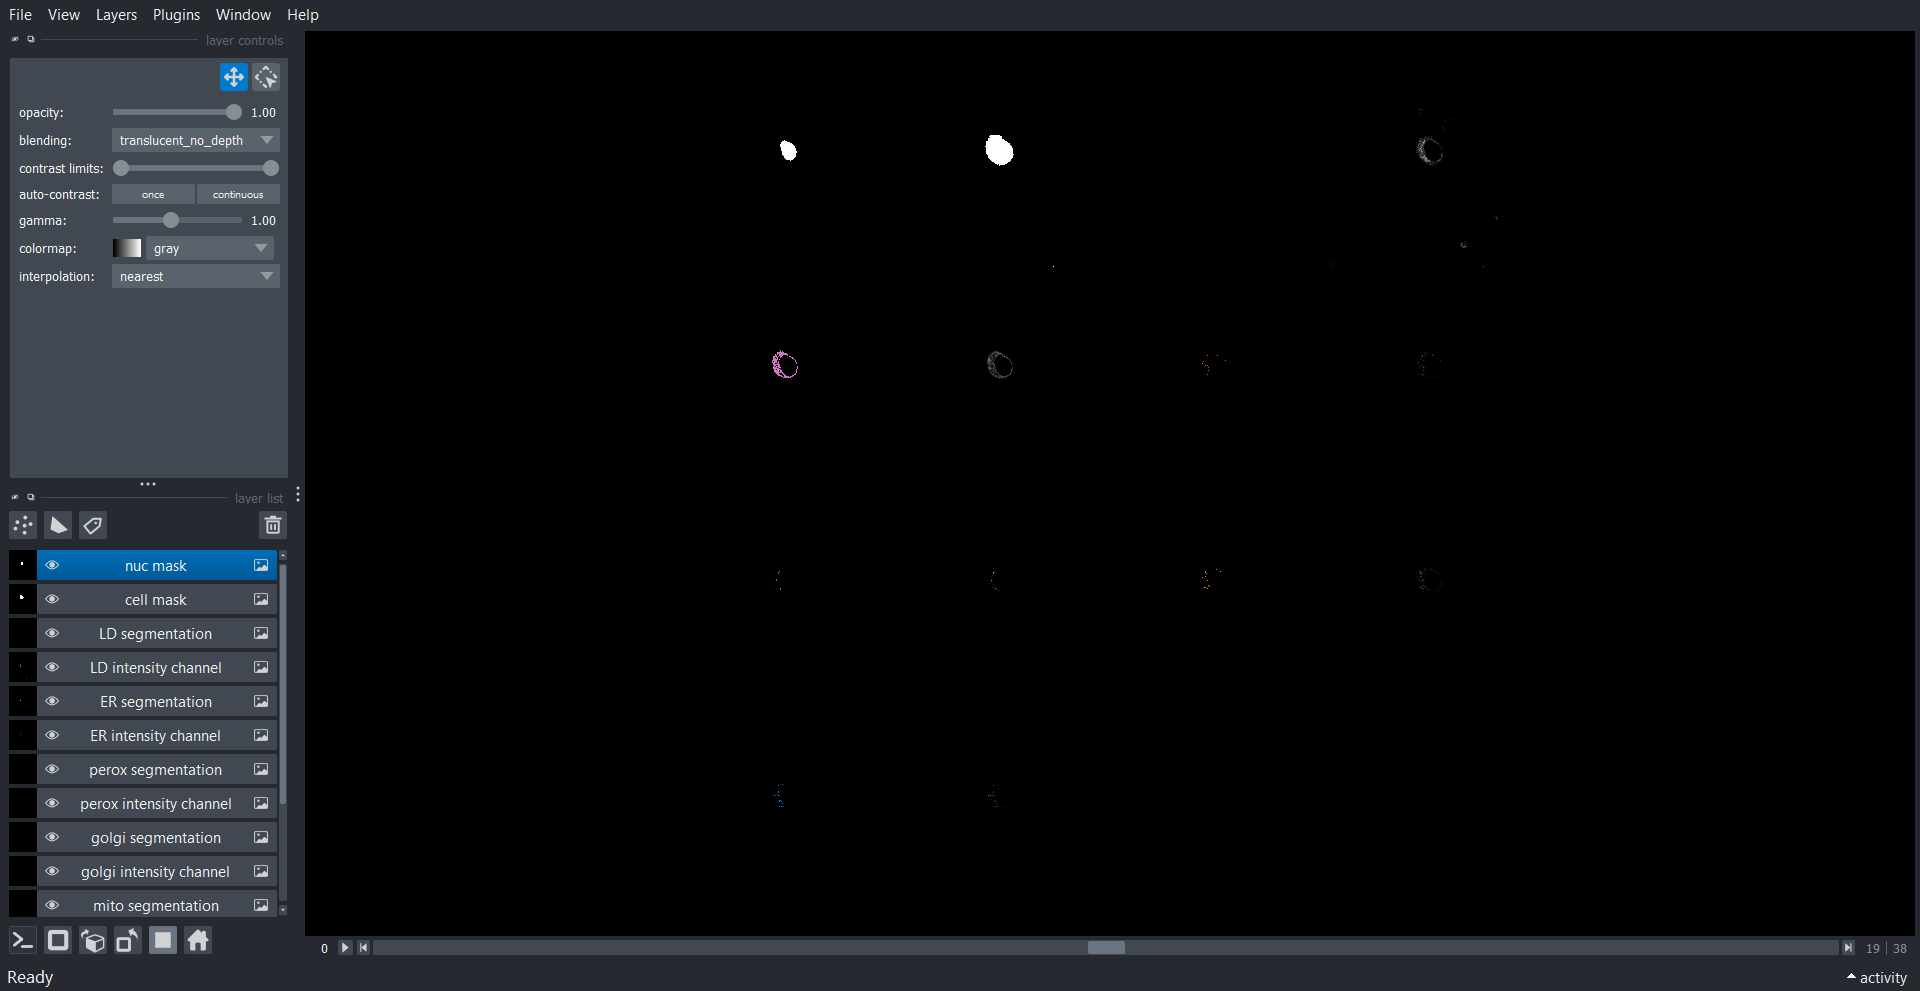

In [8]:
# find file paths for segmentations
all_suffixes = org_file_names + regions_file_names
filez = find_segmentation_tiff_files(file_path, all_suffixes, seg_data_path, suffix_separator)

# read the segmentation, masks/regions, and intensity channels into memory
intensities_list = [img_data[ch] for ch in org_channels_ordered]
organelles_list = [read_tiff_image(filez[org]) for org in org_file_names]
regions_list = [read_tiff_image(filez[reg]) for reg in regions_file_names] 

# specifiy the mask image
mask = regions_list[regions_file_names.index(mask_name)]


# define color maps for visualization throughout
n_org = len(organelles_list)
if n_org<=10:
    colors = sns.color_palette(palette="colorblind", n_colors=n_org).as_hex()
elif n_org>10 and n_org<=20:
    colors = sns.color_palette(palette="tab20", n_colors=n_org).as_hex()
else:
    colors = sns.color_palette(palette="hsv", n_colors=n_org).as_hex()
    Warnings.warn("More than 20 organelles selected. Colors may be hard to distinguish.")

# open viewer and add images
viewer = napari.Viewer()
for o, org in enumerate(org_file_names):
    viewer.add_image(intensities_list[o],
                     scale=scale,
                     name=f"{org} intensity channel")
    viewer.add_image(organelles_list[o],
                      scale=scale,
                      name=f"{org} segmentation",
                      colormap=colors[o],
                      contrast_limits=(0,1),
                      blending='additive')
    
for r, reg in enumerate(regions_file_names):
    viewer.add_image(regions_list[r],
                     scale=scale,
                     name=f"{reg} mask")
viewer.grid.enabled = True
viewer.reset_view()

print("\nThe following matching files were found and can now be viewed in Napari:")
for k,v in filez.items(): print(f"{k}: {v}")

# screenshot of viewer
nbscreenshot(viewer, canvas_only = False)

-----
### 🦠 **Quantify one or more organelles from <ins>ONE IMAGE</ins>**

#### **`STEP 1` - Select mask from regions list, if applicable**

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** The analysis outlined below can be carried out on the entire image (`mask_name`=None), or one a single region within the image (`mask_name`={region-suffix}). For example, you may wish to ensure the analysis is carried out at the single cell level, in which case you would provide the cell segmentation file as the mask. In the cell below, the cell mask is selected from the `regions` list created above. During the analysis, any organelles outside of the cell will be ignored. 

In [9]:
# specify the mask image to use during quantification based on the mask_name provided
if regions_file_names is None or regions_list is None:
    print("No regions provided. No mask or centering object will be applied before analysis.")
    mask = None
    centering_obj = None
elif mask_name is None or mask_name not in regions_file_names:
    if mask_name is not None:
        raise ValueError(f"Mask '{mask_name}' not found. No mask will be applied before analysis.")
    mask = None
    mask_name = None
else:
    mask = regions_list[regions_file_names.index(mask_name)]

# add mask to napari for visual inspection
if mask is not None:
    viewer.layers.clear()
    viewer.add_labels(mask, scale=scale, name="Mask")
    viewer.grid.enabled = False
    viewer.reset_view()
    print("Mask added to viewer for inspection.")

Mask added to viewer for inspection.


#### **`STEP 2` - Loop through the list of organelles to quantify the distribution of each**

##### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** The following code block loops through the list of organelles carrying out the following steps for each:
1) The organelle segmentation image is selected from the list of segmentations specified above
2) A check is done to ensure the segmentation files are formatted corrected (e.g., the ER should only include on object)
3) The `get_XY_distribution()` and `get_Z_distribution` functions from the [method_distribution.ipynb](method_distribution.ipynb) are carried out

*The mask defined above will be used in the analysis below; if no mask is desired, the `mask_name` variable can be updated to None.*

> ***IMPORTANT**: The zernike measurements included in the `get_XY_distribution()` function may cause an error if the "mask" object contains multiple disconnected components. The following error message will be included:*
> ```l
> ValueError: operands could not be broadcast together with shapes...
> ```
>*If zernike_degrees = None, then the zernike features are not calculated. Thus, this error has no chance of occuring in this case.*

Please specify the following needed parameters for spatial distribution analysis:

- `centering_obj`: Name of the centering object for XY distribution; this should match one of the names included in the regions_file_names list defined above.
- `num_bins`: Number of XY bins to include in the analysis
- `center_on`: Whether to start creation of the XY bins from the center of the centering object (True) or edge (False)
- `keep_center_as_bin`: To keep the center object as the first XY bin (True) or not (False); the number of specified bins will be created evenly across the chosen area
- `zernike_degrees`: The number of degrees to use when calculating Zernike features

In [10]:
#### USER INPUT REQUIRED ####
centering_obj = "nuc"
num_bins=5
center_on=False
keep_center_as_bin=True
zernike_degrees=None

In [11]:
# specify the centering image to use during quantification based on the centering object name provided
if centering_obj == None:
    print("No centering object provided. Using center of mask or entire image for distribution centering.")
    centering_img = None
elif centering_obj not in regions_file_names:
    raise ValueError(f"Centering object '{centering_obj}' not found in region names: {regions_file_names}")
else:
    centering_img = regions_list[regions_file_names.index(centering_obj)]

# empty list to collect the distribution data for each organelle
dist_tabs = []
XY_bins_imgs = []
XY_wedges_imgs = []

# loop through the list of organelles and run the get_XY_distribution and get_Z_distribution function
for j, target in enumerate(org_file_names):    
    # select segmentation and if ER, ensure it is only one object
    if target == 'ER':
        org_obj = (organelles_list[j] > 0).astype(np.uint16)
    else:
        org_obj = organelles_list[j]
    
    # run get_XY_distribution function to output a table of distribution measurements in respect to a specified object in the XY
    XY_distribution, XY_bins, XY_wedges = get_XY_distribution(mask=mask,
                                                                mask_name = mask_name,
                                                                centering_obj=centering_img,
                                                                obj=org_obj,
                                                                obj_name=target,
                                                                scale=scale,
                                                                num_bins=num_bins,
                                                                center_on=center_on,
                                                                keep_center_as_bin=keep_center_as_bin,
                                                                zernike_degrees=zernike_degrees # set to None if you wish to skip quantification of zernike features
                                                                )
    
    # if XY_bins_imgs list is empty append, if not skip
    if not XY_bins_imgs and not XY_wedges_imgs:
        XY_bins_imgs.append(XY_bins)
        XY_wedges_imgs.append(XY_wedges)
        
    # run get_Z_distribution function to output a table of distribution measurements in respect to a specified object in the Z
    Z_distribution = get_Z_distribution(mask=mask,
                                            mask_name = mask_name, 
                                            obj=org_obj,
                                            obj_name=target,
                                            center_obj=centering_img,
                                            scale=scale)

    # add table to list above
    dist_tab = pd.merge(XY_distribution, Z_distribution)
    dist_tabs.append(dist_tab)

# print each table for each organelle separately
for i, org in enumerate(org_file_names):
    print(f"{org} distribution metrics table:")
    display(dist_tabs[i])

how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
lyso distribution metrics table:


,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,cell,"(0.4106, 0.0799, 0.0799)",lyso,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[14460, 14046, 14603, 10977, 14894]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[16517, 19390, 641, 2382, 5940, 16813, 328, 6969]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[2676, 2945, 152, 792, 1301, 4263, 118, 2213], [4407, 3203, 146, 732, 1380, 1988, 6, 2184], [5226, 3569, 124, 134, 1559, 2854, 63, 1074], [3465, 3423, 0, 0, 639, 2363, 0, 1087], [743, 6250, 219, 724, 1061, 5345, 141, 411]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.8107291451368495, 0.6494947855252579, 0.870894923912768, 1.0042505372376342, 1.1226640074807146]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[37.94768044880938, 36.86121158948662, 38.322958339831494, 28.80717069755052, 39.086635726456905]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[43.34590857351207, 50.88558256586541, 1.6821897073089083, 6.251132422480217, 15.588466242456965, 44.12270756471868, 0.8607772605262431, 18.28889246526643]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739573127, 79.45656438095446, 28.723192428230888, 32.23190949324182, 63.72638480902062, 59.98

mito distribution metrics table:


,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,cell,"(0.4106, 0.0799, 0.0799)",mito,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[9671, 9246, 12930, 9567, 26862]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[13672, 11785, 3944, 4530, 10211, 12880, 3952, 7302]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[1808, 1982, 558, 875, 1137, 1684, 309, 1318], [2397, 1912, 769, 672, 1182, 1533, 122, 659], [2847, 2315, 1135, 550, 2608, 1407, 664, 1404], [2522, 2118, 341, 309, 1135, 1940, 108, 1094], [4098, 3458, 1141, 2124, 4149, 6316, 2749, 2827]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.5074947857779962, 0.36531246224618896, 0.23147233495647654, 0.5396020014407197, 0.21076283362157655]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[25.37980758094298, 24.2644711915416, 33.932469446964404, 25.106878205654173, 70.49450845199983]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[35.8797155668134, 30.927621997871267, 10.350321693644826, 11.888173750560615, 26.796940875711798, 33.80125340115248, 10.371316260974735, 19.162791330373864]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739573127, 79.45656438095446, 28.723192428230888, 32.23190949324182, 63.7

golgi distribution metrics table:


...

,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,cell,"(0.4106, 0.0799, 0.0799)",perox,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[4298, 4532, 6834, 7302, 12028]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[6850, 6056, 1723, 2152, 6806, 4962, 1510, 4935]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[745, 372, 561, 397, 674, 669, 229, 651], [890, 855, 443, 332, 610, 290, 146, 966], [1228, 917, 253, 438, 2243, 869, 136, 750], [2126, 1800, 165, 245, 905, 865, 105, 1091], [1861, 2112, 301, 740, 2374, 2269, 894, 1477]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.27578197274256966, 0.294789422152818, 0.3658732652462536, 0.5488771395705319, 0.311227119557229]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[11.279331297993272, 11.893422392393092, 17.934609141574224, 19.162791330373864, 31.565331980517236]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[17.976598276234043, 15.892887468740636, 4.521704938679015, 5.647538611745351, 17.861128155919545, 13.021880386375667, 3.9627245835202047, 12.951023721637226]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739573127, 79.45656438095446, 28.723192428230888, 32.23190949324182, 63.72638480902062, 59.986

ER distribution metrics table:


,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,cell,"(0.4106, 0.0799, 0.0799)",ER,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[105896, 93424, 112889, 110010, 310978]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[135068, 115156, 35671, 55265, 139850, 132372, 37461, 82354]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[16526, 16761, 8990, 10140, 14811, 16894, 7320, 14454], [22179, 17756, 5473, 6454, 13205, 12270, 3433, 12654], [27240, 20420, 4100, 5454, 25420, 13311, 3788, 13156], [27376, 18886, 3614, 4614, 27390, 15581, 2349, 10200], [41747, 41333, 13494, 28603, 59024, 74316, 20571, 31890]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.2778916294924533, 0.1686111009219549, 0.27526269712522655, 0.3456365233522788, 0.1752329048070665]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[277.9050877459971, 245.17455727866994, 296.25696391325323, 288.70154399540246, 816.1060698900307]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[354.46177751450796, 302.206299430366, 93.61215140314519, 145.03309543592326, 367.0112801359607, 347.38660832432885, 98.30968584321218, 216.12332473590925]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739573127, 79.4565643

LD distribution metrics table:


,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,cell,"(0.4106, 0.0799, 0.0799)",LD,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[0, 0, 0, 0, 2089]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[213, 160, 355, 48, 66, 766, 130, 351]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [213, 160, 355, 48, 66, 766, 130, 351]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.0, 0.0, 0.0, 0.0, 0.7686375063076161]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[0.0, 0.0, 0.0, 0.0, 5.482206394022323]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[0.5589803551588104, 0.4198913465981674, 0.9316339252646839, 0.12596740397945022, 0.17320518047174405, 2.0102298218387262, 0.341161719111011, 0.9211366415997297]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739573127, 79.45656438095446, 28.723192428230888, 32.23190949324182, 63.72638480902062, 59.98672750338069, 16.522724488637888, 52.788215230138356], [116.93711570667338, 92.94819821133683, 26.353430640867483, 28.68645193540355, 108.8227154336638, 65.83896314659265, 18.766518872021845, 56.441269945542416], [124.61

#### **`STEP 3` - Combine all of the tables together and add the image name as a metadata column**

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block combines the above tables together so that each organelle object is listed as a separate column in a single table. A new column is then added to specify which image the data is from.

In [12]:
# combine the lists for each organelle into one table
final_dist_tab = pd.concat(dist_tabs, ignore_index=True)

# add a new column to list the name of the image these data are derived from 
final_dist_tab.insert(loc=0,column='image_name',value=file_path.stem)

# print table for inspection
display(final_dist_tab)

,image_name,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,cell,"(0.4106, 0.0799, 0.0799)",lyso,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[14460, 14046, 14603, 10977, 14894]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[16517, 19390, 641, 2382, 5940, 16813, 328, 6969]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[2676, 2945, 152, 792, 1301, 4263, 118, 2213], [4407, 3203, 146, 732, 1380, 1988, 6, 2184], [5226, 3569, 124, 134, 1559, 2854, 63, 1074], [3465, 3423, 0, 0, 639, 2363, 0, 1087], [743, 6250, 219, 724, 1061, 5345, 141, 411]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.8107291451368495, 0.6494947855252579, 0.870894923912768, 1.0042505372376342, 1.1226640074807146]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[37.94768044880938, 36.86121158948662, 38.322958339831494, 28.80717069755052, 39.086635726456905]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[43.34590857351207, 50.88558256586541, 1.6821897073089083, 6.251132422480217, 15.588466242456965, 44.12270756471868, 0.8607772605262431, 18.28889246526643]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784, 154.8191881325768], [100.23593739

#### **`DEFINE` - The get_organelle_dist() function**

In [13]:
def _get_distribution_metrics(source_file_path: str,
                        list_obj_names: List[str],
                        list_obj_segs: List[np.ndarray],
                        list_region_names: Union[List[str], None]=None,
                        list_region_segs: Union[List[np.ndarray], None]=None,
                        mask_name: Union[str, None]=None,
                        scale: Union[tuple,None] = None,
                        centering_obj: Union[str, None]=None,
                        num_bins: Union[int, None]=5,
                        center_on: Union[bool, None]=False,
                        keep_center_as_bin: Union[bool, None]=True,
                        zernike_degrees: Union[int, None]=9) -> pd.DataFrame:
    """
    Measure the spatial distribution of multiple organelles from a single cell in respect to the center

    Parameters:
    ----------
    source_file: str
        Path to the source image file. This will be used as part of the metadata information in the output table. 
    list_obj_names: List[str]
        List of organelle names. These names should match the suffix on the segmentation image files.
    list_obj_segs: List[np.ndarray]
        List of 3D organelle segmentation arrays matching the order included in list_obj_names.
    list_region_names: Union[List[str], None]
        List of segmented region/mask names. These names should match the suffix on the segmentation image files.
        This should include:
            - a mask segmentation, such as the cell mask, for masking during distribution analysis; else, the entire image will be 
            quantified. Only one object per mask image will be analyzed. If there are more than one included, they will be combined 
            prior to analysis and the entire region will be quantified. If no mask is provided, the entire image will be quantified.
            - a centering object, such as the nucleus; else the center of the mask region will be used as the XY distribution centering 
            point.
    list_region_segs: Union[List[np.ndarray], None]
        List of 3D region segmentation arrays matching the order specified in list_region_names. Specify None if no regions are provided.
    mask_name: Union[str, None]
        Name of the region to use as the mask for analysis; if not specified, the entire image will be quantified.
    scale: Union[tuple,None] = None
        a tuple that contains the real world dimensions for each dimension in the image (Z, Y, X)
    centering_obj : Union[str, None], default=None
        Name of the region to use for centering during distribution analysis.
        This region should be included in the list_region_names and list_region_segs variables.
        If not specified, the center of the mask, or entire image if no mask was specified, will be used as the centering object.
    num_bins : Union[int, None], default=5
        Number of radial bins to create in the XY distribution analysis.
    center_on : Union[bool, None], default=True
        Whether to start creation of the XY bins from the center (True) or the edge (False) of the centering object.
    keep_center_as_bin : Union[bool, None], default=True
        Whether to keep the centering object as the first XY bin. 
    zernike_degrees : Union[int, None], default=9
        Zernike polynomial degree for circular shape/pattern analysis in the XY distribution analysis.
        If None and include_dist=True, no Zernike features will be calculated.

    Returns
    -------
    final_dist_tab : pd.DataFrame
        Dataframe for XY and Z distribution metrics for organelle in one image

    """
    # Validate inputs
    if not list_obj_names:
        raise ValueError("list_obj_names cannot be empty")
    if len(list_obj_names) != len(list_obj_segs):
        raise ValueError(f"Mismatch: {len(list_obj_names)} items in list_obj_names but {len(list_obj_segs)} items in list_obj_segs")
    if list_region_names and list_region_segs and len(list_region_names) != len(list_region_segs):
        raise ValueError(f"Mismatch: {len(list_region_names)} items in list_region_names but {len(list_region_segs)} items in list_region_segs")
    
    if isinstance(source_file_path, str): source_file_path = Path(source_file_path)
    print(f"Quantifying organelle distributions from {source_file_path.name}")

    # specify the mask image to use during quantification based on the mask_name provided
    if list_region_names is None or list_region_segs is None:
        print("No regions provided. No mask or centering object will be applied before analysis.")
        mask = None
        centering_obj = None
    elif mask_name is None or mask_name not in list_region_names:
        if mask_name is not None:
            raise ValueError(f"Mask '{mask_name}' not found. No mask will be applied before analysis.")
        mask = None
        mask_name = None
    else:
        mask = list_region_segs[list_region_names.index(mask_name)]

    # specify the centering image to use during quantification based on the centering object name provided
    if centering_obj == None:
        print("No centering object provided. Using center of mask or entire image for distribution centering.")
        centering_img = None
    elif centering_obj not in list_region_names:
        raise ValueError(f"Centering object '{centering_obj}' not found in region names: {list_region_names}")
    else:
        centering_img = list_region_segs[list_region_names.index(centering_obj)]
    
    # empty list to collect the distribution data for each organelle
    dist_tabs = []
    XY_bins_imgs = []
    XY_wedges_imgs = []

    # loop through the list of organelles and run the get_XY_distribution and get_Z_distribution function
    for j, target in enumerate(list_obj_names):    
        # select segmentation and if ER, ensure it is only one object
        if target == 'ER':
            org_obj = (list_obj_segs[j] > 0).astype(np.uint16)
        else:
            org_obj = list_obj_segs[j]

        # run get_XY_distribution function to output a table of distribution measurements in respect to a specified object in the XY
        XY_distribution, XY_bins, XY_wedges = get_XY_distribution(mask=mask,
                                                                    mask_name = mask_name,
                                                                    centering_obj=centering_img,
                                                                    obj=org_obj,
                                                                    obj_name=target,
                                                                    scale=scale,
                                                                    num_bins=num_bins,
                                                                    center_on=center_on,
                                                                    keep_center_as_bin=keep_center_as_bin,
                                                                    zernike_degrees=zernike_degrees # set to None if you wish to skip quantification of zernike features
                                                                    )
        
        # if XY_bins_imgs list is empty append, if not skip
        if not XY_bins_imgs and not XY_wedges_imgs:
            XY_bins_imgs.append(XY_bins)
            XY_wedges_imgs.append(XY_wedges)
            
        # run get_Z_distribution function to output a table of distribution measurements in respect to a specified object in the Z
        Z_distribution = get_Z_distribution(mask=mask,
                                                mask_name = mask_name, 
                                                obj=org_obj,
                                                obj_name=target,
                                                center_obj=centering_img,
                                                scale=scale)

        # add table to list above
        dist_tab = pd.merge(XY_distribution, Z_distribution)
        dist_tabs.append(dist_tab)

    # combine the lists for each organelle into one table
    final_dist_tab = pd.concat(dist_tabs, ignore_index=True)

    # add a new column to list the name of the image these data are derived from 
    final_dist_tab.insert(loc=0,column='image_name',value=source_file_path.stem)

    return final_dist_tab
    

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block applies the function above to your test image. The settings specified above are applied here.

In [14]:
# test function above
org_dist_tab = _get_distribution_metrics(source_file_path=test_img_path,
                                                                                           list_obj_names=org_file_names,
                                                                                           list_obj_segs=organelles_list,
                                                                                           list_region_names=regions_file_names,
                                                                                           list_region_segs=regions_list,
                                                                                           mask_name=mask_name,
                                                                                           scale=scale,
                                                                                           centering_obj=centering_obj,
                                                                                           num_bins=num_bins,
                                                                                           center_on=center_on,
                                                                                           keep_center_as_bin=keep_center_as_bin,
                                                                                           zernike_degrees=zernike_degrees)
# check if the output here matches the prototypes above
print("The outputs here matches the output created above:")
print(final_dist_tab.equals(org_dist_tab))

Quantifying organelle distributions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
The outputs here matches the output created above:
True


##### &#x1F453; **FYI:** This function has been added to `infer_subc.quantification.distribution` and can be imported with the following:
> ```python
> from infer_subc.quantification.distribution import get_distribution_metrics
> ```

In [15]:
from infer_subc.quantification.distribution import get_distribution_metrics

# test function from infer_subc
org_dist_tab_test = get_distribution_metrics(source_file_path=test_img_path,
                                                                                           list_obj_names=org_file_names,
                                                                                           list_obj_segs=organelles_list,
                                                                                           list_region_names=regions_file_names,
                                                                                           list_region_segs=regions_list,
                                                                                           mask_name=mask_name,
                                                                                           scale=scale,
                                                                                           centering_obj=centering_obj,
                                                                                           num_bins=num_bins,
                                                                                           center_on=center_on,
                                                                                           keep_center_as_bin=keep_center_as_bin,
                                                                                           zernike_degrees=zernike_degrees)

print("The outputs here matches the output created above:")
print(org_dist_tab.equals(org_dist_tab_test))

Quantifying organelle interactions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
The outputs here matches the output created above:
True


-----
### 🧪 **Batch process *multiple images* from a <ins>SINGLE EXPERIMENT</ins>**

#### **`STEP 1` - Check the output file paths to see if quantification data already exists**

##### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** The quantification pipeline outlined here will write new quantitative data to a csv file as each image is processed. This ensures that data is not lost if processing is interrupted. This step first checks if an output file of the same name already exists and lists any data included there. 

Specify the name of this dataset:
- `dataset_name`: A unique string identifier for this dataset. It will be included as metadata in output tables and as part of the output files names. It will be used to identify if any data has already been collected for this dataset.

In [16]:
### USER INPUT REQUIRED ###
dataset_name = "test_dataset_1"

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This step defines the output csv file paths that will be created during distribution analysis batch processing below and checks if any data from this dataset already exists there. If so, the images that have quantitative data in each file will not be processed again. 

In [17]:
# define a function to check for existing data in csv files
def _load_existing_keys_csv(csv_path, key_cols, chunksize=250_000):
    keys = set()
    if not os.path.exists(csv_path):
        return keys
    for chunk in pd.read_csv(csv_path, usecols=key_cols, chunksize=chunksize):
        keys.update(map(tuple, chunk[key_cols].itertuples(index=False, name=None)))
    return keys


# specify the columns that will be checked per table
unique_keys = ['dataset', 'image_name']

# check if any existing data is present in outfiles
dist_path = quant_data_path / f"{dataset_name}_distribution_metrics.csv"
existing_dist_keys = _load_existing_keys_csv(dist_path, unique_keys)

# show data that was found
if existing_dist_keys:
    print(f"Found existing {dataset_name} data for {len(existing_dist_keys)} images in {quant_data_path}. These images will be skipped during analysis to avoid duplicate data entries.")
else:
    print(f"No \"{dataset_name}\" data was found in {quant_data_path}. All images will be processed during analysis.")

No "test_dataset_1" data was found in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant. All images will be processed during analysis.


#### **`STEP 2` - List images and the segmentation file suffixes that should be collected for each**

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** These steps collect a list of the images included in your "raw" (intensity image) data folder. Then, the masks suffixes and organelle suffixes are combined into one list.

In [18]:
# reading list of files from the raw path
img_file_list = list_image_files(raw_data_path, raw_img_type)
print(f"Found {len(img_file_list)} images in {raw_data_path} for analysis:")
display(pd.DataFrame({"Image Name":img_file_list}))

# list of organelle segmentation and masks files to collect from each image
segs_to_collect = org_file_names + regions_file_names
print(f"The following segmentation files will be collected for each image: {segs_to_collect}")

Found 2 images in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw for analysis:


,Image Name
0,c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
1,c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff


The following segmentation files will be collected for each image: ['lyso', 'mito', 'golgi', 'perox', 'ER', 'LD', 'cell', 'nuc']


#### **`STEP 3` - Loop through the list of images and perform the distribution quantification on all organelles**

##### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** This step loops through each image listed, reads the segmentation files, formats them appropriately, and then carries out distribution via `get_distribution_metrics()`.

Specify if the quantification should be carried out with or without the scale:
- `use_scale`: True indicates that the function will use the scale metadata to produce "real world" metrics (e.g., microns, etc.). False will produce quantification results in pixel/voxel units.

*Note: the file path locations and file information provided in the beginning of the notebook will be used here for simplicity.*

In [19]:
### USER INPUT REQUIRED ###
use_scale = True

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** The block of code below loops through the list of files and runs the `get_distribution_metrics()` function on each one. The loop utilizes the following sequence of steps:
1) Find the paths for all of the organelle and mask segmentation files.
2) Collect the intensity channels and organelle segmentation files in the same order. Store them as lists.
3) Collect all of the region segmentation files in another list.
4) Determine the scale from the metadata if it is being used.
5) Run the get_distribution_metrics() function and add the resulting data table to the org_tab list.
6) Repeat the loop above for each image in the raw image list and add them sequentially to the org_tab list.

In [20]:
# define function to append data to csv after each image is processed
def _append_atomic_csv(csv_path, df):
    if df.empty:
        return
    if not os.path.exists(csv_path):
        df.to_csv(csv_path, index=False)
        return
    existing = pd.read_csv(csv_path)
    merged = pd.concat([existing, df], axis=0, ignore_index=True)
    merged = merged.drop_duplicates()  # final guard against repeat values
    fd, tmp_path = tempfile.mkstemp(prefix='append_', suffix='.csv')
    os.close(fd)
    merged.to_csv(tmp_path, index=False)
    os.replace(tmp_path, csv_path)


# loop through list of images and quantify distribution metrics if data for that image do not already exist;
for img_f in img_file_list:
    # skip files that have already been processed
    if (dataset_name, img_f.stem) in existing_dist_keys:
        print(f"Skipping {img_f.name} as it is already listed in the output file(s).")
        continue

    # process analysis for this cells
    else:
        filez = find_segmentation_tiff_files(img_f, segs_to_collect, seg_data_path, suffix_separator)

        # read in raw file and metadata
        _img_data, meta_dict = read_czi_image(filez["raw"])

        # store organelle images as list
        organelles = [read_tiff_image(filez[org]) for org in org_file_names]

        # load regions as a list based on order in list (should match order in "masks" file)
        regions = [read_tiff_image(filez[r]) for r in regions_file_names] 

        # define the scale
        if use_scale is True:
            scale_tup = meta_dict['scale']
        else:
            scale_tup = None

        dist_tab = _get_distribution_metrics(source_file_path=img_f,
                                         list_obj_names=org_file_names,
                                         list_obj_segs=organelles, 
                                         list_region_names=regions_file_names,
                                         list_region_segs=regions, 
                                         mask_name=mask_name,
                                         scale=scale_tup,
                                         centering_obj=centering_obj,
                                         num_bins=num_bins,
                                         center_on=center_on,
                                         keep_center_as_bin=keep_center_as_bin,
                                         zernike_degrees=zernike_degrees)
        
        dist_tab = dist_tab.astype(str)  # ensure all data is string to avoid dtype issues

        # save the distribution (or labels only) table data per image directly to csv
        dist_tab.insert(loc=0,column='dataset',value=dataset_name)
        _append_atomic_csv(dist_path, dist_tab)
        del dist_tab  # free up memory

Quantifying organelle distributions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
Quantifying organelle distributions from 20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff


#### **`DEFINE` - The batch_process_distribution_quant() function**

The following code combines the steps above into a single function that can be accessed as part of the `infer-subc` package. The function takes in file path information for segmentation images and the parameters necessary to quantify organelle distribution metrics. 

This function can be utilized from infer-subc using:
```python
infer_subc.quantification.distribution.batch_process_distribution_quant()
```

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block defines a prototypes of the `batch_process_distribution_quant()` function based on the steps above and tests it below.

In [21]:
def _batch_process_distribution_quant(dataset_name: str,
                             raw_path: Union[Path,str], 
                             seg_path: Union[Path,str],
                             quant_path: Union[Path, str], 
                             raw_file_type: str,
                             organelle_names: List[str],
                             region_names: Union[List[str], None]=None,
                             mask_name: Union[str, None]=None,
                             use_scale:bool=True,
                             seg_suffix:Union[str, None]=None,
                             centering_obj: Union[str, None]=None,
                             num_bins: Union[int, None]=5,
                             center_on: Union[bool, None]=False,
                             keep_center_as_bin: Union[bool, None]=True,
                             zernike_degrees: Union[int, None]=9):
    """  
    batch process distribution quantification; this function is currently optimized to process images from one file folder per image type (e.g., raw, segmentation)
    the output csv files are saved to the indicated quant_path folder

    Parameters:
    ----------
    dataset_name : str
        A unique string identifier for the dataset being processed. It will be included as metadata in output tables and as 
        part of the output files names. It will be used to identify if any data has already been collected for this dataset.
    raw_path: Union[Path,str]
        Path or str to the folder that contains the raw image files
    seg_path: Union[Path,str]
        Path or str to the folder that contains the segmentation tiff files
    quant_path: Union[Path, str]
        Path or str to the folder that the output datatables will be saved to
    raw_file_type: str
        File type of the raw images (e.g., "czi", "tiff")
    organelle_names: List[str]
        List of organelle names to analyze. These names should match the suffix on the organelle segmentation files
    region_names: Union[List[str], None]=None
        List of region names to analyze. Usually ['cell', 'nuc'] for cell mask and nucleus.
        If no regions are to be included, specify None here.
    mask_name: Union[str, None]=None
        Name of the region to use for segmentation (if any). This name should be included in the regions_name variable.
        If None, the entire image will be quantified.
    use_scale: bool=True
        Whether to apply scaling to the quantitative data; scaled data will be in real world units (e.g., microns) rather than pixels/voxels
    seg_suffix:Union[str, None]=None
        Any additional text that is included in the segmentation tiff files between the file stem and the segmentation suffix, not including the initial "-"
    
    Returns:
    --------
    None
        Saves output files to the specified quantification path
    """

    start = time.time()
    count = 0

    # create path objects if inputs are strings
    if isinstance(raw_path, str): raw_path = Path(raw_path)
    if isinstance(seg_path, str): seg_path = Path(seg_path)
    if isinstance(quant_path, str): quant_path = Path(quant_path)
    
    # create directory is it doesn't exist
    if not Path.exists(quant_path):
        Path.mkdir(quant_path)
        print(f"Output file path not found. Making {quant_path}.")
    
    # specify the columns that will be checked per table
    unique_keys = ['dataset', 'image_name']

    # check if any existing data is present in outfiles
    dist_path = quant_path / f"{dataset_name}_distribution_metrics.csv"
    existing_dist_keys = _load_existing_keys_csv(dist_path, unique_keys)

    # list of organelle segmentation and masks files to collect from each image
    segs_to_collect = organelle_names + region_names if region_names is not None else organelle_names

    # reading list of files from the raw path
    img_file_list = list_image_files(raw_path, raw_file_type)
    len_file_list = len(img_file_list)

    # loop through list of images and quantify distribution metrics if data for that image do not already exist;
    for img_f in img_file_list:
        img_start = time.time()
        count = count + 1
        # skip files that have already been processed
        if (dataset_name, img_f.stem) in existing_dist_keys:
            print(f"Skipping {img_f.name} as it is already listed in the output file(s).")
            continue

        # process analysis for this cells
        else:
            filez = find_segmentation_tiff_files(img_f, segs_to_collect, seg_path, seg_suffix)

            # read in raw file and metadata
            _img_data, meta_dict = read_czi_image(filez["raw"])

            # store organelle images as list
            organelles = [read_tiff_image(filez[org]) for org in organelle_names]

            # load regions as a list based on order in list (should match order in "masks" file)
            regions = [read_tiff_image(filez[r]) for r in region_names] 

            # define the scale
            if use_scale is True:
                scale_tup = meta_dict['scale']
            else:
                scale_tup = None

            dist_tab = _get_distribution_metrics(source_file_path=img_f,
                                            list_obj_names=organelle_names,
                                            list_obj_segs=organelles, 
                                            list_region_names=region_names,
                                            list_region_segs=regions, 
                                            mask_name=mask_name,
                                            scale=scale_tup,
                                            centering_obj=centering_obj,
                                            num_bins=num_bins,
                                            center_on=center_on,
                                            keep_center_as_bin=keep_center_as_bin,
                                            zernike_degrees=zernike_degrees)
            
            dist_tab = dist_tab.astype(str)  # ensure all data is string to avoid dtype issues

            # save the distribution (or labels only) table data per image directly to csv
            dist_tab.insert(loc=0,column='dataset',value=dataset_name)
            _append_atomic_csv(dist_path, dist_tab)
            del dist_tab  # free up memory

            end2 = time.time()
            print(f"Completed distribution quantification of {meta_dict['file_name']} in {(end2-img_start)/60} mins.")
            print(f"{count}/{len_file_list} images have been processed.")
            print(f"Time elapsed: {(end2-img_start)/60} mins")

    end = time.time()
    print(f"Distribution quantification for {count} files is COMPLETE! Files saved to '{quant_path}'.")
    print(f"It took {(end - start)/60} minutes to quantify these files.")

In [22]:
# define a new dataset name for comparison
dataset_name2 = "test_dataset_1-comparison"

_batch_process_distribution_quant(dataset_name=dataset_name2,
                        seg_path = seg_data_path,
                        quant_path = quant_data_path, 
                        raw_path = raw_data_path, 
                        raw_file_type = raw_img_type,
                        organelle_names = org_file_names,
                        region_names = regions_file_names,
                        mask_name = mask_name,
                        use_scale = use_scale,
                        seg_suffix = suffix_separator,
                        centering_obj=centering_obj,
                        num_bins=num_bins,
                        center_on=center_on,
                        keep_center_as_bin=keep_center_as_bin,
                        zernike_degrees=zernike_degrees)

# compare the output files from both dataset runs to ensure they are identical
dist_file1 = quant_data_path / f"{dataset_name}_distribution_metrics.csv"
dist_file2 = quant_data_path / f"{dataset_name2}_distribution_metrics.csv"

# determine if files are identical except for the dataset name column
if dist_file1.exists() and dist_file2.exists():
    dist_1 = pd.read_csv(dist_file1)
    dist_2 = pd.read_csv(dist_file2)
    dist_2['dataset'] = dist_1['dataset']  # set dataset names to be the same for comparison
    print("\nDistribution metrics files identical:", dist_1.equals(dist_2))

Quantifying organelle distributions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff in 0.8825826803843181 mins.
1/2 images have been processed.
Time elapsed: 0.8825826803843181 mins
Quantifying organelle distributions from 20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff in 0.17280382712682088 mins.
2/2 images have been processed.
Time elapsed:

##### &#x1F453; **FYI:** This function has been added to `infer_subc.quantification.distribution` and can be imported with the following:
> ```python
> from infer_subc.quantification.distribution import batch_process_distribution_quant
> ```

In [23]:
from infer_subc.quantification.distribution import batch_process_distribution_quant

# define a new dataset name for comparison
dataset_name3 = "test_dataset_1-comparison-2"

batch_process_distribution_quant(dataset_name=dataset_name3,
                        seg_path = seg_data_path,
                        quant_path = quant_data_path, 
                        raw_path = raw_data_path, 
                        raw_file_type = raw_img_type,
                        organelle_names = org_file_names,
                        region_names = regions_file_names,
                        mask_name = mask_name,
                        use_scale = use_scale,
                        seg_suffix = suffix_separator,
                        centering_obj=centering_obj,
                        num_bins=num_bins,
                        center_on=center_on,
                        keep_center_as_bin=keep_center_as_bin,
                        zernike_degrees=zernike_degrees)

# compare the output files from both dataset runs to ensure they are identical
morpho_file1 = quant_data_path / f"{dataset_name}_distribution_metrics.csv"
morpho_file3 = quant_data_path / f"{dataset_name3}_distribution_metrics.csv"

# determine if files are identical except for the dataset name column
if morpho_file1.exists() and morpho_file3.exists():
    morph_1 = pd.read_csv(morpho_file1)
    morph_3 = pd.read_csv(morpho_file3)
    morph_3['dataset'] = morph_1['dataset']  # set dataset names to be the same for comparison
    print("\nDistribution metrics files identical:", morph_1.equals(morph_3))

Quantifying organelle interactions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff in 0.847543199857076 mins.
1/2 images have been processed.
Time elapsed: 0.847543199857076 mins
Quantifying organelle interactions from 20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff in 0.15345322688420612 mins.
2/2 images have been processed.
Time elapsed: 0.1

-----
### 🧮 **Summarize metrics *per image/mask* across <INS>ONE OR MORE EXPERIMENTS</ins>**

#### **`STEP 1` - Get the orgnaelle morphology .csv files**

#### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** Here, the data output from batch_process_distribution_quant() from one or more datasets is combined before summarization.

Please specify the list file paths to include in this analysis:
- `csv_path_list`: a list of file paths that include the output csv files from batch_process_distribution_quant() for one or more datasets. If there is more than one dataset in each location, they will all be read in here as long as each dataset has a unique name (as specified the by dataset_name variable).

In [24]:
### USER INPUT REQUIRED ###
csv_path_list = [quant_data_path]

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** These steps collect all of the distribution .csv quantification files from the list of locations and combines them.

Here, we will just use the single data path specified as quant_data_path earlier in the notebook, but multiple paths can be specified is desired. This path will have a few datasets in it if the above was run through fully.

In [25]:
###################
# Read in the csv files and combine them into one
###################
# create empty list to hold the distribution tables from different experiments
dist_tabs = []

# loop through all of the locations listed above and find the _distribution files; append them to the list above
for loc in csv_path_list:

    # list all csv files in the location
    files_store = sorted(loc.glob("*.csv"))

    # find the unique datasets in this location based on the prefixes before "_distribution_metrics"
    prefixes = set(f.name.split("_distribution_metrics")[0] for f in files_store if "_distribution_metrics" in f.name)
    print(f"Found the following datasets in {loc}:", prefixes)
    for prefix in prefixes:
        # select only the files from this dataset
        files_subset = [f for f in files_store if f.name.startswith(prefix +"_distribution_metrics")]
        for file in files_subset:
            stem = file.stem
            if "_dist" in stem:
                test_dist = pd.read_csv(file, index_col=0)
                dist_tabs.append(test_dist)

# combine the dist lists found above into one table
dist_df = pd.concat(dist_tabs,axis=0, join='outer').reset_index()

print("Morphology metrics from all datasets:")
dist_df

Found the following datasets in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant: {'test_dataset_1-comparison', 'test_dataset_1-comparison-2', 'test_dataset_1'}
Morphology metrics from all datasets:


,dataset,image_name,mask_name,scale,object,XY_n_bins,XY_bins,XY_cell_vox_cnt_perbin,XY_obj_vox_cnt_perbin,XY_center_vox_cnt_perbin,XY_n_pix_perbin,XY_portion_pix_perbin,XY_n_wedges,XY_wedges,XY_cell_vox_cnt_perwedge,XY_obj_vox_cnt_perwedge,XY_center_vox_cnt_perwedge,XY_n_pix_perwedge,XY_portion_pix_perwedge,XY_wedges_perbin,XY_cell_vox_cnt_wedges_perbin,XY_obj_vox_cnt_wedges_perbin,XY_center_vox_cnt_wedges_perbin,XY_n_pix_wedges_perbin,XY_cell_cv_perbin,XY_obj_cv_perbin,XY_center_cv_perbin,XY_cell_vol_perbin,XY_obj_vol_perbin,XY_center_vol_perbin,XY_cell_vol_perwedge,XY_obj_vol_perwedge,XY_center_vol_perwedge,XY_cell_vol_wedges_perbin,XY_obj_vol_wedges_perbin,XY_center_vol_wedges_perbin,XY_area_perbin,XY_area_perwedge,XY_area_wedges_perbin,Z_n_slices,Z_slices,Z_cell_vox_cnt,Z_obj_vox_cnt,Z_center_vox_cnt,Z_height,Z_cell_volume,Z_obj_volume,Z_center_volume
0,test_dataset_1-comparison,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,cell,"(0.4106, 0.0799, 0.0799)",lyso,5,"[1, 2, 3, 4, 5]","[427821, 165251, 196163, 207616, 1011691]","[14460, 14046, 14603, 10977, 14894]","[175238, 0, 0, 0, 0]","[16860.0, 8258.0, 12460.0, 18674.0, 216510.0]","[0.06181212925554146, 0.030275478255768765, 0.045680849971770264, 0.06846261576025986, 0.7937689267566597]",8,"[1, 2, 3, 4, 5, 6, 7, 8]","[319633, 296234, 127814, 182981, 351404, 358956, 137498, 234022]","[16517, 19390, 641, 2382, 5940, 16813, 328, 6969]","[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715]","[38215.0, 39623.0, 18382.0, 28101.0, 43057.0, 52482.0, 19785.0, 33117.0]","[0.1401038267793901, 0.14526583615019686, 0.0673920854077914, 0.10302388162573965, 0.15785556639121284, 0.19240949985701822, 0.0725357637794121, 0.12141354000923882]","[[1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8]]","[[57387, 50728, 46695, 51065, 66818, 54038, 42096, 58994], [38195, 30277, 10945, 12282, 24283, 22858, 6296, 20115], [44559, 35418, 10042, 10931, 41467, 25088, 7151, 21507], [47486, 37115, 8702, 10176, 48109, 28226, 6286, 21516], [132006, 142696, 51430, 98527, 170727, 228746, 75669, 111890]]","[[2676, 2945, 152, 792, 1301, 4263, 118, 2213], [4407, 3203, 146, 732, 1380, 1988, 6, 2184], [5226, 3569, 124, 134, 1559, 2854, 63, 1074], [3465, 3423, 0, 0, 639, 2363, 0, 1087], [743, 6250, 219, 724, 1061, 5345, 141, 411]]","[[21353, 15957, 20949, 23350, 30508, 18828, 20578, 23715], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]]","[[2127.0, 1845.0, 1972.0, 2125.0, 2640.0, 2006.0, 1720.0, 2425.0], [1688.0, 1330.0, 723.0, 731.0, 1224.0, 1091.0, 325.0, 1146.0], [2397.0, 1908.0, 985.0, 949.0, 2563.0, 1506.0, 472.0, 1680.0], [3473.0, 3000.0, 1254.0, 1322.0, 4161.0, 2356.0, 734.0, 2374.0], [28530.0, 31540.0, 13448.0, 22974.0, 32469.0, 45523.0, 16534.0, 25492.0]]","[0.05584855577120961, 0.1323818281512559, 0.19744502799963695, 0.2256929003033245, 0.09011663872663153]","[0.8107291451368495, 0.6494947855252579, 0.870894923912768, 1.0042505372376342, 1.1226640074807146]","[0.10101250106309162, 0.0, 0.0, 0.0, 0.0]","[1122.739598706091, 433.671655729336, 514.794663892102, 544.851011345782, 2655.001852070291]","[37.94768044880938, 36.86121158948662, 38.322958339831494, 28.80717069755052, 39.086635726456905]","[459.88074871981036, 0.0, 0.0, 0.0, 0.0]","[838.8195674200753, 777.4130823010095, 335.42495358811357, 480.2008655742454, 922.1968672498901, 942.0157388093236, 360.83887734096766, 614.148829459977]","[43.34590857351207, 50.88558256586541, 1.6821897073089083, 6.251132422480217, 15.588466242456965, 44.12270756471868, 0.8607772605262431, 18.28889246526643]","[56.03712452444168, 41.876288860418484, 54.976898874281304, 61.27789339417006, 80.06278251260557, 49.41071421093935, 54.003275814356805, 62.23577052859712]","[[150.60190442018146, 133.12655143894898, 122.54266518375891, 134.01094758772138, 175.35187498122718, 141.81305367169855, 110.47341328997784,

#### **`STEP 2` - Calculate summary statistics for the distribution data per image/mask**

##### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** The distribution metrics for each organelle and the centering object per cell is summarized by first representing the bin/wedge/slice counts as histogram frequencies. The histograms then summarized using the mean, median, standard deviation, mode, min, max, range, skew, kurtosis, and variance.

In [26]:
# extract centering object metrics
nuc_dist_df = dist_df[["dataset", "image_name", 'scale',
                    "XY_bins", "XY_center_vox_cnt_perbin", f"XY_{mask_name}_vox_cnt_perbin", "XY_center_cv_perbin",
                    "XY_wedges", "XY_center_vox_cnt_perwedge", f"XY_{mask_name}_vox_cnt_perwedge",
                    "Z_slices", "Z_center_vox_cnt", f"Z_{mask_name}_vox_cnt"]].drop_duplicates(subset=['dataset', 'image_name'])
nuc_dist_df.columns = nuc_dist_df.columns.str.replace('center', 'obj', regex=False)
nuc_dist_df.insert(loc=3,column='object',value='nuc')
nuc_dist_df.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)

# select relevant columns from dist dataset
dist_df2 = dist_df[list(nuc_dist_df.reset_index().columns)]
dist_df2.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)

# combine
combo_dist_df = pd.concat([nuc_dist_df, dist_df2], axis=0)

# loop through each row of data and calculate histogram statistics
hist_dfs = []
for ind in combo_dist_df.index:
    selection = combo_dist_df.loc[[ind]].reset_index()
    bins_df = pd.DataFrame()
    wedges_df = pd.DataFrame()
    Z_df = pd.DataFrame()
    CV_df = pd.DataFrame()

    # select relevant columns into different groups
    try:
        bins_df[['bins', 'masks', 'obj']] = selection[['XY_bins', f'XY_{mask_name}_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin']]
        wedges_df[['bins', 'masks', 'obj']] = selection[['XY_wedges', f'XY_{mask_name}_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge']]
        Z_df[['bins', 'masks', 'obj']] = selection[['Z_slices', f'Z_{mask_name}_vox_cnt', 'Z_obj_vox_cnt']]
    except:
        bins_df[['bins', 'masks', 'obj']] = selection[['XY_bins', f'XY_{mask_name}_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin']]
        wedges_df[['bins', 'masks', 'obj']] = selection[['XY_wedges', f'XY_{mask_name}_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge']]
        Z_df[['bins', 'masks', 'obj']] = selection[['Z_slices', f'Z_{mask_name}_vox_cnt', 'Z_obj_vox_cnt']]
    CV_df[['XY_obj_cv_perbin']] = selection[['XY_obj_cv_perbin']]

    dfs = [selection[['dataset', 'image_name', 'scale', 'object']].reset_index()]

    # for each group of data, calculate histogram statistics
    for df, prefix in zip([bins_df, wedges_df, Z_df, CV_df], ["XY_bins_", "XY_wedges_", "Z_slices_", "CV_perbin_"]):
        if prefix != "CV_perbin_":
            single_df = pd.DataFrame(list(zip(df["bins"].values[0][1:-1].split(", "), 
                                            df["obj"].values[0][1:-1].split(", "), 
                                            df["masks"].values[0][1:-1].split(", "))), columns =['bins', 'obj', 'mask']).astype(int)
            
            if "Z_" in prefix:
                single_df =  single_df.drop(single_df[single_df['mask'] == 0].index)
                single_df['bins'] = (single_df["bins"]/max(single_df.bins)*9.99).apply(np.floor)+1
                single_df = single_df.groupby("bins").agg(['sum']).reset_index()
                single_df.columns = ['bins',"obj","mask"]
        
            single_df['mask_fract'] = single_df['mask']/single_df['mask'].max()
            # single_df['obj_normed_tocell'] = (single_df["obj"]*single_df["mask_fract"]).fillna(0)
            single_df['obj_perc_per_bin'] = (single_df["obj"] / single_df["obj"].sum())*100
            single_df['obj_portion_normed_tobin'] = (single_df["obj_perc_per_bin"]/single_df["mask_fract"]).fillna(0)

            sumstats_df = pd.DataFrame()

            s = single_df['bins'].repeat(single_df['obj_portion_normed_tobin']*100)

            sumstats_df['hist_mean']=[s.mean()]
            sumstats_df['hist_median']=[s.median()]
            if single_df['obj_portion_normed_tobin'].sum() != 0: sumstats_df['hist_mode']=[s.mode().iloc[0]]
            else: sumstats_df['hist_mode']=['NaN']
            sumstats_df['hist_min']=[s.min()]
            sumstats_df['hist_max']=[s.max()]
            sumstats_df['hist_range']=[s.max() - s.min()]
            sumstats_df['hist_stdev']=[s.std()]
            sumstats_df['hist_skew']=[s.skew()]
            sumstats_df['hist_kurtosis']=[s.kurtosis()]
            sumstats_df['hist_var']=[s.var()]
            sumstats_df.columns = [prefix+col for col in sumstats_df.columns]
            sumstats_df.reset_index(drop=True, inplace=True)

            dfs.append(sumstats_df)
             
        if prefix == 'CV_perbin_':
            CV_df = pd.DataFrame(list(zip(df["XY_obj_cv_perbin"].values[0][1:-1].split(", "))), columns =['CV']).astype(float)
            sumstats_CV_df = pd.DataFrame()
            sumstats_CV_df['XY_bin_CV_mean'] = CV_df.mean()
            sumstats_CV_df['XY_bin_CV_median'] = CV_df.median()
            sumstats_CV_df['XY_bin_CV_std'] = CV_df.std()
            sumstats_CV_df.reset_index(drop=True, inplace=True)
            sumstats_df = pd.concat([sumstats_df, sumstats_CV_df], axis=1)

            dfs.append(sumstats_df)
    
    # combine dataframes per group together
    combined_df = pd.concat(dfs,axis=1).drop(columns="index")
    combined_df.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)
    hist_dfs.append(combined_df)

# combine data from each row of data in the original table together
dist_summary = pd.concat(hist_dfs).sort_values(by=['dataset', 'image_name', 'scale', 'object'])
dist_summary.reset_index(inplace=True)

print("Distribution summary metrics per image (or mask region):")
display(dist_summary)

Distribution summary metrics per image (or mask region):


,dataset,image_name,scale,object,XY_bins_hist_mean,XY_bins_hist_median,XY_bins_hist_mode,XY_bins_hist_min,XY_bins_hist_max,XY_bins_hist_range,XY_bins_hist_stdev,XY_bins_hist_skew,XY_bins_hist_kurtosis,XY_bins_hist_var,XY_wedges_hist_mean,XY_wedges_hist_median,XY_wedges_hist_mode,XY_wedges_hist_min,XY_wedges_hist_max,XY_wedges_hist_range,XY_wedges_hist_stdev,XY_wedges_hist_skew,XY_wedges_hist_kurtosis,XY_wedges_hist_var,Z_slices_hist_mean,Z_slices_hist_median,Z_slices_hist_mode,Z_slices_hist_min,Z_slices_hist_max,Z_slices_hist_range,Z_slices_hist_stdev,Z_slices_hist_skew,Z_slices_hist_kurtosis,Z_slices_hist_var,Z_slices_hist_mean,Z_slices_hist_median,Z_slices_hist_mode,Z_slices_hist_min,Z_slices_hist_max,Z_slices_hist_range,Z_slices_hist_stdev,Z_slices_hist_skew,Z_slices_hist_kurtosis,Z_slices_hist_var,XY_bin_CV_mean,XY_bin_CV_median,XY_bin_CV_std
0,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",ER,3.037874,3.0,3,1.0,5.0,4.0,1.219842,0.016612,-0.983780,1.488014,4.372091,4.0,1,1.0,8.0,7.0,2.337367,0.036712,-1.260104,5.463285,5.763930,5.0,3.0,2.0,10.0,8.0,2.443540,0.265066,-1.190092,5.970890,5.763930,5.0,3.0,2.0,10.0,8.0,2.443540,0.265066,-1.190092,5.970890,0.248527,0.275263,0.075442
1,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",LD,5.000000,5.0,5,5.0,5.0,0.0,0.000000,0.000000,0.000000,0.000000,4.824787,6.0,3,1.0,8.0,7.0,2.260124,-0.050742,-1.360010,5.108160,3.731673,4.0,3.0,2.0,5.0,3.0,0.883577,-0.028128,-0.888036,0.780709,3.731673,4.0,3.0,2.0,5.0,3.0,0.883577,-0.028128,-0.888036,0.780709,0.153728,0.000000,0.343745
2,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",golgi,2.497376,2.0,2,1.0,5.0,4.0,0.829901,0.326228,-0.522501,0.688735,3.252594,2.0,2,1.0,8.0,7.0,2.171431,0.714521,-0.853138,4.715113,4.669198,5.0,5.0,3.0,7.0,4.0,0.945292,0.102053,-0.574140,0.893577,4.669198,5.0,5.0,3.0,7.0,4.0,0.945292,0.102053,-0.574140,0.893577,1.441933,1.089388,0.721959
3,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",lyso,2.730538,3.0,2,1.0,5.0,4.0,1.095478,0.214023,-0.722280,1.200073,3.765577,2.0,2,1.0,8.0,7.0,2.480396,0.408459,-1.318837,6.152362,5.598847,5.0,5.0,2.0,10.0,8.0,2.321788,0.458302,-0.955536,5.390701,5.598847,5.0,5.0,2.0,10.0,8.0,2.321788,0.458302,-0.955536,5.390701,0.891607,0.870895,0.181428
4,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",mito,2.990923,3.0,3,1.0,5.0,4.0,1.172839,0.085234,-0.834661,1.375551,4.278027,4.0,1,1.0,8.0,7.0,2.376182,0.096633,-1.332546,5.646240,5.076031,4.0,4.0,2.0,10.0,8.0,2.267940,0.776429,-0.447822,5.143551,5.076031,4.0,4.0,2.0,10.0,8.0,2.267940,0.776429,-0.447822,5.143551,0.370929,0.365312,0.151850
5,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",nuc,1.000000,1.0,1,1.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,4.715268,4.0,3,1.0,8.0,7.0,2.186151,0.013274,-1.192532,4.779256,6.513714,7.0,7.0,4.0,8.0,4.0,1.095554,-0.327082,-0.681792,1.200239,6.513714,7.0,7.0,4.0,8.0,4.0,1.095554,-0.327082,-0.681792,1.200239,0.020203,0.000000,0.045174
6,test_dataset_1,20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome,"(0.4106, 0.0799, 0.0799)",perox,3.095778,3.0,4,1.0,5.0,4.0,1.118163,-0.122800,-0.785531,1.250288,4.344751,4.0,1,1.0,8.0,7.0,2.432749,0.107517,-1.325454,5.918268,4.991306,5.0,3.0,2.0,10.0,8.0,1.982469,0.761736,-0.082708,3.930183,4.991306,5.0,3.0,2.0,10.0,8.0,1.982469,0.761736,-0.082708,3.930183,0.359310,0.311227,0.111165
7,test_dataset_1,20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome,"(0.3891, 0.0706, 0.0706)",ER,3.172377,3.0,4,1.0,5.0,4.0,1.307394,-0.093236,-1.142241,1.709280,4.665988,5.0,3,1.0,8.0,7.0,2.205267,-0.128230,-1.221188,4.8

#### **`STEP 4` - Unstack the organelle names and save file**

#### &#x1F6D1; &#x270D; **User Input Required:**

&#x1F453; **FYI:** In this step each table is reformated to "unstack" the organelle column into the rows. In the resulting table, each row corresponds to a single image. The table is then exported.

Please specify the following:

- `out_prefix`: A string used to name the output files. For example, if "date" is specified as out_prefix, the output files would be named "date_distribution_summarystats.csv".

In [27]:
out_prefix = "all_datasets_1"

In [28]:
# export before unstacking
if (Path(quant_data_path) / f"{out_prefix}_per_org_distribution_summarystats.csv").exists():
    raise FileExistsError(f"CAUTION: {out_prefix}_per_org_distribution_summarystats.csv already exists and will not be overwritten. Move the existing file, change the `out_prefix` or `out_path` to continue without error.")
else:
    dist_summary.to_csv(str(quant_data_path) + f"/{out_prefix}_per_org_distribution_summarystats.csv")

# unstack and format interaction distribution summary table
dist_summary.insert(2, "mask_name", mask_name) ## TODO: change after dist is updated to include mask_name
dist_final = dist_summary.set_index(['dataset', 'image_name', 'mask_name', 'scale', 'object']).unstack(-1)
dist_final.columns = ["_".join((col_name[1], col_name[0])) for col_name in dist_final.columns.to_flat_index()]
dist_final = dist_final.reset_index()
display(dist_final)

###################
# export summary sheets
###################
if (Path(quant_data_path) / f"{out_prefix}_distribution_summarystats.csv").exists():
    raise FileExistsError(f"CAUTION: {out_prefix}_distribution_summarystats.csv already exists and will not be overwritten. Move the existing file, change the `out_prefix` or `out_path` to continue without error.")
else:
    dist_final.to_csv(str(quant_data_path) + f"/{out_prefix}_distribution_summarystats.csv")
    print(f"Exported distribution summary statistics (after unstacking) to {quant_data_path}/{out_prefix}_distribution_summarystats.csv")
print(f"Organelle distribution summary is complete.")

,dataset,image_name,mask_name,scale,ER_XY_bins_hist_mean,LD_XY_bins_hist_mean,golgi_XY_bins_hist_mean,lyso_XY_bins_hist_mean,mito_XY_bins_hist_mean,nuc_XY_bins_hist_mean,perox_XY_bins_hist_mean,ER_XY_bins_hist_median,LD_XY_bins_hist_median,golgi_XY_bins_hist_median,lyso_XY_bins_hist_median,mito_XY_bins_hist_median,nuc_XY_bins_hist_median,perox_XY_bins_hist_median,ER_XY_bins_hist_mode,LD_XY_bins_hist_mode,golgi_XY_bins_hist_mode,lyso_XY_bins_hist_mode,mito_XY_bins_hist_mode,nuc_XY_bins_hist_mode,perox_XY_bins_hist_mode,ER_XY_bins_hist_min,LD_XY_bins_hist_min,golgi_XY_bins_hist_min,lyso_XY_bins_hist_min,mito_XY_bins_hist_min,nuc_XY_bins_hist_min,perox_XY_bins_hist_min,ER_XY_bins_hist_max,LD_XY_bins_hist_max,golgi_XY_bins_hist_max,lyso_XY_bins_hist_max,mito_XY_bins_hist_max,nuc_XY_bins_hist_max,perox_XY_bins_hist_max,ER_XY_bins_hist_range,LD_XY_bins_hist_range,golgi_XY_bins_hist_range,lyso_XY_bins_hist_range,mito_XY_bins_hist_range,nuc_XY_bins_hist_range,perox_XY_bins_hist_range,ER_XY_bins_hist_stdev,LD_XY_bins_hist_stdev,golgi_XY_bins_hist_stdev,lyso_XY_bins_hist_stdev,mito_XY_bins_hist_stdev,nuc_XY_bins_hist_stdev,perox_XY_bins_hist_stdev,ER_XY_bins_hist_skew,LD_XY_bins_hist_skew,golgi_XY_bins_hist_skew,lyso_XY_bins_hist_skew,mito_XY_bins_hist_skew,nuc_XY_bins_hist_skew,perox_XY_bins_hist_skew,ER_XY_bins_hist_kurtosis,LD_XY_bins_hist_kurtosis,golgi_XY_bins_hist_kurtosis,lyso_XY_bins_hist_kurtosis,mito_XY_bins_hist_kurtosis,nuc_XY_bins_hist_kurtosis,perox_XY_bins_hist_kurtosis,ER_XY_bins_hist_var,LD_XY_bins_hist_var,golgi_XY_bins_hist_var,lyso_XY_bins_hist_var,mito_XY_bins_hist_var,nuc_XY_bins_hist_var,perox_XY_bins_hist_var,ER_XY_wedges_hist_mean,LD_XY_wedges_hist_mean,golgi_XY_wedges_hist_mean,lyso_XY_wedges_hist_mean,mito_XY_wedges_hist_mean,nuc_XY_wedges_hist_mean,perox_XY_wedges_hist_mean,ER_XY_wedges_hist_median,LD_XY_wedges_hist_median,golgi_XY_wedges_hist_median,lyso_XY_wedges_hist_median,mito_XY_wedges_hist_median,nuc_XY_wedges_hist_median,perox_XY_wedges_hist_median,ER_XY_wedges_hist_mode,LD_XY_wedges_hist_mode,golgi_XY_wedges_hist_mode,lyso_XY_wedges_hist_mode,mito_XY_wedges_hist_mode,nuc_XY_wedges_hist_mode,perox_XY_wedges_hist_mode,ER_XY_wedges_hist_min,LD_XY_wedges_hist_min,golgi_XY_wedges_hist_min,lyso_XY_wedges_hist_min,mito_XY_wedges_hist_min,nuc_XY_wedges_hist_min,perox_XY_wedges_hist_min,ER_XY_wedges_hist_max,LD_XY_wedges_hist_max,golgi_XY_wedges_hist_max,lyso_XY_wedges_hist_max,mito_XY_wedges_hist_max,nuc_XY_wedges_hist_max,perox_XY_wedges_hist_max,ER_XY_wedges_hist_range,LD_XY_wedges_hist_range,golgi_XY_wedges_hist_range,lyso_XY_wedges_hist_range,mito_XY_wedges_hist_range,nuc_XY_wedges_hist_range,perox_XY_wedges_hist_range,ER_XY_wedges_hist_stdev,LD_XY_wedges_hist_stdev,golgi_XY_wedges_hist_stdev,lyso_XY_wedges_hist_stdev,mito_XY_wedges_hist_stdev,nuc_XY_wedges_hist_stdev,perox_XY_wedges_hist_stdev,ER_XY_wedges_hist_skew,LD_XY_wedges_hist_skew,golgi_XY_wedges_hist_skew,lyso_XY_wedges_hist_skew,mito_XY_wedges_hist_skew,nuc_XY_wedges_hist_skew,perox_XY_wedges_hist_skew,ER_XY_wedges_hist_kurtosis,LD_XY_wedges_hist_kurtosis,golgi_XY_wedges_hist_kurtosis,lyso_XY_wedges_hist_kurtosis,mito_XY_wedges_hist_kurtosis,nuc_XY_wedges_hist_kurtosis,perox_XY_wedges_hist_kurtosis,ER_XY_wedges_hist_var,LD_XY_wedges_hist_var,golgi_XY_wedges_hist_var,lyso_XY_wedges_hist_var,mito_XY_wedges_hist_var,nuc_XY_wedges_hist_var,perox_XY_wedges_hist_var,ER_Z_slices_hist_mean,LD_Z_slices_hist_mean,golgi_Z_slices_hist_mean,lyso_Z_slices_hist_mean,mito_Z_slices_hist_mean,nuc_Z_slices_hist_mean,perox_Z_slices_hist_mean,ER_Z_slices_hist_median,LD_Z_slices_hist_median,golgi_Z_slices_hist_median,lyso_Z_slices_hist_median,mito_Z_slices_hist_median,nuc_Z_slices_hist_median,perox_Z_slices_hist_median,ER_Z_slices_hist_mode,LD_Z_slices_hist_mode,golgi_Z_slices_hist_mode,lyso_Z_slices_hist_mode,mito_Z_slices_hist_mode,nuc_Z_slices_hist_mode,perox_Z_slices_hist_mode,ER_Z_slices_hist_min,LD_Z_slices_hist_min,golgi_Z_slices_hist_min,lyso_Z_slices_hist_

Exported distribution summary statistics (after unstacking) to c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant/all_datasets_1_distribution_summarystats.csv
Organelle distribution summary is complete.


#### **`DEFINE` - The batch_distribution_summary_stats() function**
The following code combines the steps above into a single function that can be accessed as part of the `infer-subc` package. The function takes in file paths to the batch_process_distribution_quant() function. The quantifitive information is exported to csv files.

This function can be utilized from infer-subc using:
```python
infer_subc.quantification.distribution.batch_distribution_summary_stats()
```

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block defines a prototypes of the `batch_distribution_summary_stats()` function based on the steps above and tests it below.

In [29]:
def _batch_distribution_summary_stats(out_prefix: str,
                                      csv_path_list: List[str],
                                      out_path: str,
                                      mask_name: str = "mask"):
    """" 
    Batch process interaction quantification summary statistics from multiple datasets.

    Parameters:
    -----------
    out_prefix: str
        The prefix used to name the output file. An "_" will be included between this prefix and the file suffix.
    csv_path_list: List[str],
        A list of path strings where .csv files to analyze are located.
    out_path: str,
        A path string where the summary data file will be output to
    splitter: str, default="X"
        The character used to split interaction site names.
    mask_name: str = "mask"
        Named of the region to used as the mask for analysis accross all datasets
    """

    # for keeping track of dataset and file numbers
    ds_count = 0
    fl_count = 0

    ###################
    # Read in the csv files and combine them into one
    ###################
    # create empty list to hold the distribution tables from different experiments
    dist_tabs = []

    # loop through all of the locations listed above and find the _distribution files; append them to the list above
    for loc in csv_path_list:

        # list all csv files in the location
        files_store = sorted(loc.glob("*.csv"))

        # find the unique datasets in this location based on the prefixes before "_distribution_metrics"
        prefixes = set(f.name.split("_distribution_metrics")[0] for f in files_store if "_distribution_metrics" in f.name)
        print(f"Found the following datasets in {loc}:", prefixes)
        for prefix in prefixes:
            ds_count += 1
            # select only the files from this dataset
            files_subset = [f for f in files_store if f.name.startswith(prefix +"_distribution_metrics")]
            for file in files_subset:
                fl_count += 1
                stem = file.stem
                if "_dist" in stem:
                    test_dist = pd.read_csv(file, index_col=0)
                    dist_tabs.append(test_dist)

    # combine the dist lists found above into one table
    dist_df = pd.concat(dist_tabs,axis=0, join='outer').reset_index()

    print(f"Found {fl_count} files from {ds_count} dataset(s) across {len(csv_path_list)} location(s).")

    # extract centering object metrics
    nuc_dist_df = dist_df[["dataset", "image_name", 'scale',
                        "XY_bins", "XY_center_vox_cnt_perbin", f"XY_{mask_name}_vox_cnt_perbin", "XY_center_cv_perbin",
                        "XY_wedges", "XY_center_vox_cnt_perwedge", f"XY_{mask_name}_vox_cnt_perwedge",
                        "Z_slices", "Z_center_vox_cnt", f"Z_{mask_name}_vox_cnt"]].drop_duplicates(subset=['dataset', 'image_name'])
    nuc_dist_df.columns = nuc_dist_df.columns.str.replace('center', 'obj', regex=False)
    nuc_dist_df.insert(loc=3,column='object',value='nuc')
    nuc_dist_df.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)

    # select relevant columns from dist dataset
    dist_df2 = dist_df[list(nuc_dist_df.reset_index().columns)]
    dist_df2.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)

    # combine
    combo_dist_df = pd.concat([nuc_dist_df, dist_df2], axis=0)

    # loop through each row of data and calculate histogram statistics
    hist_dfs = []
    for ind in combo_dist_df.index:
        selection = combo_dist_df.loc[[ind]].reset_index()
        bins_df = pd.DataFrame()
        wedges_df = pd.DataFrame()
        Z_df = pd.DataFrame()
        CV_df = pd.DataFrame()

        # select relevant columns into different groups
        try:
            bins_df[['bins', 'masks', 'obj']] = selection[['XY_bins', f'XY_{mask_name}_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin']]
            wedges_df[['bins', 'masks', 'obj']] = selection[['XY_wedges', f'XY_{mask_name}_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge']]
            Z_df[['bins', 'masks', 'obj']] = selection[['Z_slices', f'Z_{mask_name}_vox_cnt', 'Z_obj_vox_cnt']]
        except:
            bins_df[['bins', 'masks', 'obj']] = selection[['XY_bins', f'XY_{mask_name}_vox_cnt_perbin', 'XY_obj_vox_cnt_perbin']]
            wedges_df[['bins', 'masks', 'obj']] = selection[['XY_wedges', f'XY_{mask_name}_vox_cnt_perwedge', 'XY_obj_vox_cnt_perwedge']]
            Z_df[['bins', 'masks', 'obj']] = selection[['Z_slices', f'Z_{mask_name}_vox_cnt', 'Z_obj_vox_cnt']]
        CV_df[['XY_obj_cv_perbin']] = selection[['XY_obj_cv_perbin']]

        dfs = [selection[['dataset', 'image_name', 'scale', 'object']].reset_index()]

        # for each group of data, calculate histogram statistics
        for df, prefix in zip([bins_df, wedges_df, Z_df, CV_df], ["XY_bins_", "XY_wedges_", "Z_slices_", "CV_perbin_"]):
            if prefix != "CV_perbin_":
                single_df = pd.DataFrame(list(zip(df["bins"].values[0][1:-1].split(", "), 
                                                df["obj"].values[0][1:-1].split(", "), 
                                                df["masks"].values[0][1:-1].split(", "))), columns =['bins', 'obj', 'mask']).astype(int)
                
                if "Z_" in prefix:
                    single_df =  single_df.drop(single_df[single_df['mask'] == 0].index)
                    single_df['bins'] = (single_df["bins"]/max(single_df.bins)*9.99).apply(np.floor)+1
                    single_df = single_df.groupby("bins").agg(['sum']).reset_index()
                    single_df.columns = ['bins',"obj","mask"]
            
                single_df['mask_fract'] = single_df['mask']/single_df['mask'].max()
                # single_df['obj_normed_tocell'] = (single_df["obj"]*single_df["mask_fract"]).fillna(0)
                single_df['obj_perc_per_bin'] = (single_df["obj"] / single_df["obj"].sum())*100
                single_df['obj_portion_normed_tobin'] = (single_df["obj_perc_per_bin"]/single_df["mask_fract"]).fillna(0)

                sumstats_df = pd.DataFrame()

                s = single_df['bins'].repeat(single_df['obj_portion_normed_tobin']*100)

                sumstats_df['hist_mean']=[s.mean()]
                sumstats_df['hist_median']=[s.median()]
                if single_df['obj_portion_normed_tobin'].sum() != 0: sumstats_df['hist_mode']=[s.mode().iloc[0]]
                else: sumstats_df['hist_mode']=['NaN']
                sumstats_df['hist_min']=[s.min()]
                sumstats_df['hist_max']=[s.max()]
                sumstats_df['hist_range']=[s.max() - s.min()]
                sumstats_df['hist_stdev']=[s.std()]
                sumstats_df['hist_skew']=[s.skew()]
                sumstats_df['hist_kurtosis']=[s.kurtosis()]
                sumstats_df['hist_var']=[s.var()]
                sumstats_df.columns = [prefix+col for col in sumstats_df.columns]
                sumstats_df.reset_index(drop=True, inplace=True)

                dfs.append(sumstats_df)
                
            if prefix == 'CV_perbin_':
                CV_df = pd.DataFrame(list(zip(df["XY_obj_cv_perbin"].values[0][1:-1].split(", "))), columns =['CV']).astype(float)
                sumstats_CV_df = pd.DataFrame()
                sumstats_CV_df['XY_bin_CV_mean'] = CV_df.mean()
                sumstats_CV_df['XY_bin_CV_median'] = CV_df.median()
                sumstats_CV_df['XY_bin_CV_std'] = CV_df.std()
                sumstats_CV_df.reset_index(drop=True, inplace=True)
                sumstats_df = pd.concat([sumstats_df, sumstats_CV_df], axis=1)

                dfs.append(sumstats_df)
        
        # combine dataframes per group together
        combined_df = pd.concat(dfs,axis=1).drop(columns="index")
        combined_df.set_index(['dataset', 'image_name', 'scale', 'object'], inplace=True)
        hist_dfs.append(combined_df)

    # combine data from each row of data in the original table together
    dist_summary = pd.concat(hist_dfs).sort_values(by=['dataset', 'image_name', 'scale', 'object'])
    dist_summary.reset_index(inplace=True)

    # export before unstacking
    if (Path(out_path) / f"{out_prefix}_per_org_distribution_summarystats.csv").exists():
        raise FileExistsError(f"CAUTION: {out_prefix}_per_org_distribution_summarystats.csv already exists and will not be overwritten. Move the existing file, change the `out_prefix` or `out_path` to continue without error.")
    else:
        dist_summary.to_csv(str(out_path) + f"/{out_prefix}_per_org_distribution_summarystats.csv")
    
    # unstack and format interaction distribution summary table
    dist_summary.insert(2, "mask_name", mask_name) ## TODO: change after dist is updated to include mask_name
    dist_final = dist_summary.set_index(['dataset', 'image_name', 'mask_name', 'scale', 'object']).unstack(-1)
    dist_final.columns = ["_".join((col_name[1], col_name[0])) for col_name in dist_final.columns.to_flat_index()]
    dist_final = dist_final.reset_index()

    ###################
    # export summary sheets
    ###################
    if (Path(out_path) / f"{out_prefix}_distribution_summarystats.csv").exists():
        raise FileExistsError(f"CAUTION: {out_prefix}_distribution_summarystats.csv already exists and will not be overwritten. Move the existing file, change the `out_prefix` or `out_path` to continue without error.")
    else:
        dist_final.to_csv(str(out_path) + f"/{out_prefix}_distribution_summarystats.csv", mode='x')
        print(f"Exported distribution summary statistics (after unstacking) to {out_path}/{out_prefix}_distribution_summarystats.csv")
    print(f"Organelle distribution summary is complete.")
    return dist_final

#### &#x1F3C3; **Run code; no user input required**

&#x1F453; **FYI:** This code block applies the function above to your test image. The settings specified above are applied here.

In [30]:
# define new out_prefix for comparison
out_prefix2 = "all_datasets_1-comparison"

# test the function above
test_org_summary = _batch_distribution_summary_stats(out_prefix= out_prefix2,
                                                  csv_path_list = csv_path_list,
                                                  out_path = quant_data_path,
                                                  mask_name = mask_name)

# compare the output files from both dataset runs to ensure they are identical
dist_file1 = quant_data_path / f"{out_prefix}_distribution_summarystats.csv"
dist_file2 = quant_data_path / f"{out_prefix2}_distribution_summarystats.csv"

# determine if files are identical except for the dataset name column
if dist_file1.exists() and dist_file2.exists():
    dist_1 = pd.read_csv(dist_file1)
    dist_2 = pd.read_csv(dist_file2)
    print("\nDistribution summarystats files identical:", dist_1.equals(dist_2))

Found the following datasets in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant: {'test_dataset_1-comparison', 'test_dataset_1-comparison-2', 'test_dataset_1'}
Found 3 files from 3 dataset(s) across 1 location(s).
Exported distribution summary statistics (after unstacking) to c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant/all_datasets_1-comparison_distribution_summarystats.csv
Organelle distribution summary is complete.

Distribution summarystats files identical: True


##### &#x1F453; **FYI:** This function has been added to `infer_subc.quantification.distribution` and can be imported with the following:
> ```python
> from infer_subc.quantification.distribution import batch_distribution_summary_stats
> ```

In [31]:
from infer_subc.quantification.distribution import batch_distribution_summary_stats

# define new out_prefix for comparison
out_prefix3 = "all_datasets_1-FINAL"

# test the function above
test_org_summary = batch_distribution_summary_stats(out_prefix= out_prefix3,
                                                  csv_path_list = csv_path_list,
                                                  out_path = quant_data_path,
                                                  mask_name = mask_name)

# compare the output files from both dataset runs to ensure they are identical
morpho_file3 = quant_data_path / f"{out_prefix3}_distribution_summarystats.csv"
morpho_file2 = quant_data_path / f"{out_prefix2}_distribution_summarystats.csv"

# determine if files are identical except for the dataset name column
if morpho_file3.exists() and morpho_file2.exists():
    morph_3 = pd.read_csv(morpho_file3)
    morph_2 = pd.read_csv(morpho_file2)
    print("\nMorphology summarystats files identical:", morph_3.equals(morph_2))

Found the following datasets in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant: {'test_dataset_1-comparison', 'test_dataset_1-comparison-2', 'test_dataset_1'}
Found 3 files from 3 dataset(s) across 1 location(s).
Exported distribution summary statistics (after unstacking) to c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant/all_datasets_1-FINAL_distribution_summarystats.csv
Organelle distribution summary is complete.

Morphology summarystats files identical: True


-----
-----

## **EXECUTE QUANTIFICATION** <a id='execute'></a>

### **`STEP 1` - 🧪 Batch process *multiple cells* from a <ins>SINGLE EXPERIMENT</ins>**

#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify the following information about your data: 
- `dataset_name`: A unique string identifier for the dataset being processed. It will be included as metadata in output tables and as part of the output files names. It will be used to identify if any data has already been collected for this dataset.
- `raw_path`: Path or str to the folder that contains the raw image files.
- `seg_path`: Path or str to the folder that contains the segmentation tiff files.
- `quant_path`: Path or str to the folder that the output datatables will be saved to.
- `raw_file_type`: File type of the raw images (e.g., "czi", "tiff").
- `organelle_names`: List of organelle names to analyze. These names should match the suffix on the organelle segmentation files
- `organelle_channels`: List of intensity channel indices in the raw files corresponding to each organelle included in organelle_names. The order should match organelle_names.
- `region_names`: List of region names to analyze. Usually ['cell', 'nuc'] for cell mask and nucleus.
- `mask_name`: Name of the mask to use for segmentation (if any). If none, the entire image will be quantified.
- `use_scale`: Whether to apply scaling to the images
- `seg_suffix`: Suffix to use for the segmentation files (if any).
- `centering_obj`: Name of the region to use for centering distribution analysis. This region should be included in the list_region_names and list_region_segs variables. If not specified, the center of the mask, or entire image if no mask was specified, will be used as the centering object.
- `num_bins`: Number of radial bins to create in the XY distribution analysis
- `center_on`: Whether to start creation of the XY bins from the center of the centering object (True) or edge (False)
- `keep_center_as_bin`: Whether to keep centering object as the first XY bin
- `zernike_degrees`: Zernike polynomial degree for shape analysis in the XY distribution analysis. If None and include_dist=True, no Zernike features will be calculated

The defaults below utilize the user input from the `IMPORTS` section, but can be adjusted as necessary.

In [35]:
### USER INPUT REQUIRED ###
dataset_name= f"{date.today().strftime('%Y%m%d')}"
raw_path=raw_data_path
seg_path=seg_data_path
quant_path=quant_data_path
raw_file_type=raw_img_type
organelle_names=org_file_names
region_names=regions_file_names
mask_name=mask_name
use_scale=True
seg_suffix=suffix_separator
centering_obj='nuc'
num_bins=5
center_on=False
keep_center_as_bin=True
zernike_degrees=None

#### &#x1F3C3; **Run code; no user input required**
&#x1F453; **FYI:** This code block uses the inputs provided above to run the batch processing. The table that is saved to you files is also printed below for easy access.

In [36]:
batch_dist_table = batch_process_distribution_quant(dataset_name,
                                                raw_path,
                                                seg_path, 
                                                quant_path, 
                                                raw_file_type,
                                                organelle_names,
                                                region_names,
                                                mask_name,
                                                use_scale,
                                                seg_suffix,
                                                centering_obj,
                                                num_bins,
                                                center_on,
                                                keep_center_as_bin,
                                                zernike_degrees)

batch_dist_table

Quantifying organelle interactions from 20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
how did we have missing labels?
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20230727_C2-121_conditioned_well 4_cell 1_untreated_Linear unmixing_0_cmle.ome.tiff in 0.9025361975034077 mins.
1/2 images have been processed.
Time elapsed: 0.9025361975034077 mins
Quantifying organelle interactions from 20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff
Completed distribution quantification of c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\raw\20240118_iN D7 TRC1 ctrl_Z 9_Linear unmixing_0_cmle.ome.tiff in 0.17378708918889363 mins.
2/2 images have been processed.
Time elapsed: 0

### **`STEP 2` - 🧮 Summarize metrics *per cell* across <INS>ONE OR MORE EXPERIMENTS</ins>**

#### &#x1F6D1; &#x270D; **User Input Required:**

Please specify the following information about your data: 
- `out_prefix`: The prefix used to name the output file. An "_" will be included between this prefix and the file suffix.
- `csv_path_list`: A list of path strings where .csv files to analyze are located.
- `out_path`: A path string where the summary data file will be output to

The defaults below utilize the user input from the `IMPORTS` section, but can be adjusted as necessary.

In [37]:
### USER INPUT REQUIRED ###
csv_path_list = [quant_data_path]
out_path = quant_data_path
out_prefix = f"{date.today().strftime('%Y%m%d')}"

# mask_name was already set in the beginning of the notebook

#### &#x1F3C3; **Run code; no user input required**
&#x1F453; **FYI:** This code block uses the inputs provided above to run the batch processing. The table that is saved to you files is also printed below for easy access.

In [39]:
out = batch_distribution_summary_stats(csv_path_list = csv_path_list,
                                       out_path = quant_data_path,
                                       out_prefix = out_prefix,
                                       mask_name = mask_name)

out

Found the following datasets in c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant: {'test_dataset_1-comparison', 'test_dataset_1-comparison-2', 'test_dataset_1', '20260108'}
Found 4 files from 4 dataset(s) across 1 location(s).
Exported distribution summary statistics (after unstacking) to c:\Users\redre\Documents\CohenLab\scohen_lab_repo\infer-subc\sample_data\example_quant\quant/20260108_distribution_summarystats.csv
Organelle distribution summary is complete.


,dataset,image_name,mask_name,scale,ER_XY_bins_hist_mean,LD_XY_bins_hist_mean,golgi_XY_bins_hist_mean,lyso_XY_bins_hist_mean,mito_XY_bins_hist_mean,nuc_XY_bins_hist_mean,perox_XY_bins_hist_mean,ER_XY_bins_hist_median,LD_XY_bins_hist_median,golgi_XY_bins_hist_median,lyso_XY_bins_hist_median,mito_XY_bins_hist_median,nuc_XY_bins_hist_median,perox_XY_bins_hist_median,ER_XY_bins_hist_mode,LD_XY_bins_hist_mode,golgi_XY_bins_hist_mode,lyso_XY_bins_hist_mode,mito_XY_bins_hist_mode,nuc_XY_bins_hist_mode,perox_XY_bins_hist_mode,ER_XY_bins_hist_min,LD_XY_bins_hist_min,golgi_XY_bins_hist_min,lyso_XY_bins_hist_min,mito_XY_bins_hist_min,nuc_XY_bins_hist_min,perox_XY_bins_hist_min,ER_XY_bins_hist_max,LD_XY_bins_hist_max,golgi_XY_bins_hist_max,lyso_XY_bins_hist_max,mito_XY_bins_hist_max,nuc_XY_bins_hist_max,perox_XY_bins_hist_max,ER_XY_bins_hist_range,LD_XY_bins_hist_range,golgi_XY_bins_hist_range,lyso_XY_bins_hist_range,mito_XY_bins_hist_range,nuc_XY_bins_hist_range,perox_XY_bins_hist_range,ER_XY_bins_hist_stdev,LD_XY_bins_hist_stdev,golgi_XY_bins_hist_stdev,lyso_XY_bins_hist_stdev,mito_XY_bins_hist_stdev,nuc_XY_bins_hist_stdev,perox_XY_bins_hist_stdev,ER_XY_bins_hist_skew,LD_XY_bins_hist_skew,golgi_XY_bins_hist_skew,lyso_XY_bins_hist_skew,mito_XY_bins_hist_skew,nuc_XY_bins_hist_skew,perox_XY_bins_hist_skew,ER_XY_bins_hist_kurtosis,LD_XY_bins_hist_kurtosis,golgi_XY_bins_hist_kurtosis,lyso_XY_bins_hist_kurtosis,mito_XY_bins_hist_kurtosis,nuc_XY_bins_hist_kurtosis,perox_XY_bins_hist_kurtosis,ER_XY_bins_hist_var,LD_XY_bins_hist_var,golgi_XY_bins_hist_var,lyso_XY_bins_hist_var,mito_XY_bins_hist_var,nuc_XY_bins_hist_var,perox_XY_bins_hist_var,ER_XY_wedges_hist_mean,LD_XY_wedges_hist_mean,golgi_XY_wedges_hist_mean,lyso_XY_wedges_hist_mean,mito_XY_wedges_hist_mean,nuc_XY_wedges_hist_mean,perox_XY_wedges_hist_mean,ER_XY_wedges_hist_median,LD_XY_wedges_hist_median,golgi_XY_wedges_hist_median,lyso_XY_wedges_hist_median,mito_XY_wedges_hist_median,nuc_XY_wedges_hist_median,perox_XY_wedges_hist_median,ER_XY_wedges_hist_mode,LD_XY_wedges_hist_mode,golgi_XY_wedges_hist_mode,lyso_XY_wedges_hist_mode,mito_XY_wedges_hist_mode,nuc_XY_wedges_hist_mode,perox_XY_wedges_hist_mode,ER_XY_wedges_hist_min,LD_XY_wedges_hist_min,golgi_XY_wedges_hist_min,lyso_XY_wedges_hist_min,mito_XY_wedges_hist_min,nuc_XY_wedges_hist_min,perox_XY_wedges_hist_min,ER_XY_wedges_hist_max,LD_XY_wedges_hist_max,golgi_XY_wedges_hist_max,lyso_XY_wedges_hist_max,mito_XY_wedges_hist_max,nuc_XY_wedges_hist_max,perox_XY_wedges_hist_max,ER_XY_wedges_hist_range,LD_XY_wedges_hist_range,golgi_XY_wedges_hist_range,lyso_XY_wedges_hist_range,mito_XY_wedges_hist_range,nuc_XY_wedges_hist_range,perox_XY_wedges_hist_range,ER_XY_wedges_hist_stdev,LD_XY_wedges_hist_stdev,golgi_XY_wedges_hist_stdev,lyso_XY_wedges_hist_stdev,mito_XY_wedges_hist_stdev,nuc_XY_wedges_hist_stdev,perox_XY_wedges_hist_stdev,ER_XY_wedges_hist_skew,LD_XY_wedges_hist_skew,golgi_XY_wedges_hist_skew,lyso_XY_wedges_hist_skew,mito_XY_wedges_hist_skew,nuc_XY_wedges_hist_skew,perox_XY_wedges_hist_skew,ER_XY_wedges_hist_kurtosis,LD_XY_wedges_hist_kurtosis,golgi_XY_wedges_hist_kurtosis,lyso_XY_wedges_hist_kurtosis,mito_XY_wedges_hist_kurtosis,nuc_XY_wedges_hist_kurtosis,perox_XY_wedges_hist_kurtosis,ER_XY_wedges_hist_var,LD_XY_wedges_hist_var,golgi_XY_wedges_hist_var,lyso_XY_wedges_hist_var,mito_XY_wedges_hist_var,nuc_XY_wedges_hist_var,perox_XY_wedges_hist_var,ER_Z_slices_hist_mean,LD_Z_slices_hist_mean,golgi_Z_slices_hist_mean,lyso_Z_slices_hist_mean,mito_Z_slices_hist_mean,nuc_Z_slices_hist_mean,perox_Z_slices_hist_mean,ER_Z_slices_hist_median,LD_Z_slices_hist_median,golgi_Z_slices_hist_median,lyso_Z_slices_hist_median,mito_Z_slices_hist_median,nuc_Z_slices_hist_median,perox_Z_slices_hist_median,ER_Z_slices_hist_mode,LD_Z_slices_hist_mode,golgi_Z_slices_hist_mode,lyso_Z_slices_hist_mode,mito_Z_slices_hist_mode,nuc_Z_slices_hist_mode,perox_Z_slices_hist_mode,ER_Z_slices_hist_min,LD_Z_slices_hist_min,golgi_Z_slices_hist_min,lyso_Z_slices_hist_

-----
-----
# 🎉 **CONGRATULATIONS!!**
### **You've successfully quantified distribution using the modular `2.3_organelle_distribution` notebook.**

Continue on to other quantification notebooks as needed:
- [2.1 Organelle morphology](2.1_organelle_morphology.ipynb)
- [2.2 Organelle interactions](2.2_organelle_interactions.ipynb)
- [2.4 Cell morphology](2.4_cell_region_morphology.ipynb)